# System rekomendacyjny z grupowaniem użytkowników

Analiza łączy dwa podejścia opisane w pracy magisterskiej:
- **K-means clustering** użytkowników wg cech demograficznych i behawioralnych (Wu Qingyang et al., 2021)
- **Filtrowanie kolaboracyjne** w obrębie klastrów (Liu Xiaojun, 2017)
- **Porównanie** z bazowym CF bez klastrowania — metryki MAE i RMSE (Lee et al., 2012)

## 1. Importy i wczytanie danych

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

DATA_PATH = '/Users/zuzia/Documents/Recommendation-system/archive-2/'

users         = pd.read_csv(DATA_PATH + 'users.csv')
movies        = pd.read_csv(DATA_PATH + 'movies.csv')
watch_history = pd.read_csv(DATA_PATH + 'watch_history.csv')
reviews       = pd.read_csv(DATA_PATH + 'reviews.csv')

print(f'Uzytownicy:        {users.shape}')
print(f'Filmy:             {movies.shape}')
print(f'Historia ogladania:{watch_history.shape}')
print(f'Recenzje:          {reviews.shape}')

Uzytownicy:        (10300, 16)
Filmy:             (1040, 18)
Historia ogladania:(105000, 12)
Recenzje:          (15450, 12)


## 2. Czyszczenie i przygotowanie danych

In [2]:
# --- Uzytkownicy ---
users = users[(users['age'] >= 13) & (users['age'] <= 90)].copy()
users['gender']         = users['gender'].fillna('Unknown')
users['household_size'] = users['household_size'].fillna(users['household_size'].median())
users['monthly_spend']  = users['monthly_spend'].fillna(users['monthly_spend'].median())

# --- Historia ogladania ---
watch_history['watch_duration_minutes'] = watch_history['watch_duration_minutes'].fillna(
    watch_history['watch_duration_minutes'].median())
watch_history['progress_percentage'] = watch_history['progress_percentage'].fillna(
    watch_history['progress_percentage'].median())
watch_history['watch_date'] = pd.to_datetime(watch_history['watch_date'])

# --- Recenzje ---
reviews = reviews.dropna(subset=['rating']).copy()
reviews['rating'] = pd.to_numeric(reviews['rating'], errors='coerce')
reviews = reviews.dropna(subset=['rating'])

# --- Filmy ---
movies = movies[movies['duration_minutes'] > 0].copy()

print('Dane po czyszczeniu:')
print(f'  Uzytkownicy:       {len(users):,}')
print(f'  Historia sesji:    {len(watch_history):,}')
print(f'  Recenzje (oceny):  {len(reviews):,}')
print(f'  Filmy:             {len(movies):,}')

Dane po czyszczeniu:
  Uzytkownicy:       8,751
  Historia sesji:    105,000
  Recenzje (oceny):  15,450
  Filmy:             1,039


In [ ]:
# Weryfikacja liczebnosci po czyszczeniu
print('Dane po czyszczeniu:')
print(f'  Uzytkownicy:       {len(users):,}')
print(f'  Historia sesji:    {len(watch_history):,}')
print(f'  Recenzje (oceny):  {len(reviews):,}')
print(f'  Filmy:             {len(movies):,}')
print()
print('Braki danych po czyszczeniu:')
print(f'  users - monthly_spend:  {users["monthly_spend"].isna().sum()}')
print(f'  users - gender:         {users["gender"].isna().sum()}')
print(f'  watch_history - duration: {watch_history["watch_duration_minutes"].isna().sum()}')
print(f'  reviews - rating:       {reviews["rating"].isna().sum()}')


Dane po czyszczeniu:
  Uzytkownicy:       8,751
  Historia sesji:    105,000
  Recenzje (oceny):  15,450
  Filmy:             1,039

Braki danych po czyszczeniu:
  users - monthly_spend:  0
  users - gender:         0
  watch_history - duration: 0
  reviews - rating:       0


## 3. Inżynieria cech użytkowników

Tworzymy profil kazdego uzytkownika laczac cechy demograficzne z behawioralnymi (Wu Qingyang et al., 2021).

In [4]:
# Cechy behawioralne z historii ogladania
behav = watch_history.groupby('user_id').agg(
    total_sessions        = ('session_id', 'count'),
    avg_watch_duration    = ('watch_duration_minutes', 'mean'),
    avg_progress          = ('progress_percentage', 'mean'),
    completed_ratio       = ('action', lambda x: (x == 'completed').mean()),
    unique_movies_watched = ('movie_id', 'nunique')
).reset_index()

# Srednia ocena uzytkownika (explicit feedback)
avg_rating = reviews.groupby('user_id')['rating'].mean().reset_index()
avg_rating.columns = ['user_id', 'avg_rating']

# Kodowanie cech kategorycznych
le_gender = LabelEncoder()
le_plan   = LabelEncoder()
le_device = LabelEncoder()

users_enc = users[['user_id','age','gender','subscription_plan',
                    'monthly_spend','household_size','primary_device']].copy()
users_enc['gender_enc'] = le_gender.fit_transform(users_enc['gender'].astype(str))
users_enc['plan_enc']   = le_plan.fit_transform(users_enc['subscription_plan'].astype(str))
users_enc['device_enc'] = le_device.fit_transform(users_enc['primary_device'].astype(str))

# Scalenie wszystkich cech
user_profiles = users_enc.merge(behav, on='user_id', how='left')
user_profiles = user_profiles.merge(avg_rating, on='user_id', how='left')

# Uzupelnianie brakow
fill_cols = ['total_sessions','avg_watch_duration','avg_progress',
             'completed_ratio','unique_movies_watched','avg_rating']
for col in fill_cols:
    user_profiles[col] = user_profiles[col].fillna(user_profiles[col].median())


print(f'Profil uzytkowników: {user_profiles.shape}') 
user_profiles[['user_id','age','monthly_spend','total_sessions', 'avg_watch_duration','completed_ratio','avg_rating']].head()

Profil uzytkowników: (8751, 16)


,user_id,age,monthly_spend,total_sessions,avg_watch_duration,completed_ratio,avg_rating
0,user_00001,43.0,36.06,13,65.230769,0.538462,4.000000
1,user_00002,38.0,14.59,15,50.973333,0.333333,3.500000
2,user_00003,32.0,11.71,9,73.433333,0.444444,4.000000
3,user_00005,21.0,9.54,10,68.560000,0.200000,3.333333
4,user_00006,43.0,13.48,12,41.583333,0.250000,3.000000


## 4. Analiza cech przed klastrami

### 4.1 Macierz korelacji — wykluczenie redundantnych zmiennych

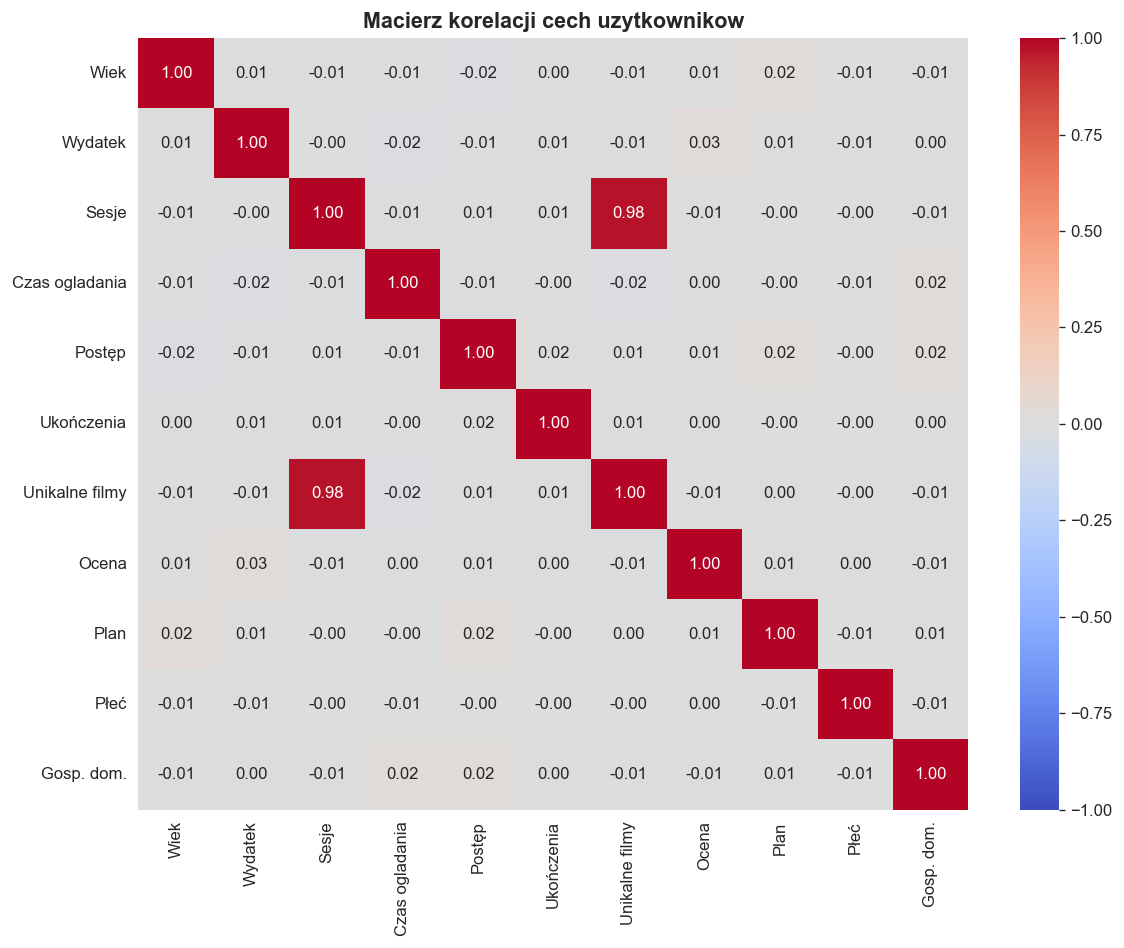

Pary zmiennych z |korelacja| > 0.8 (potencjalna redundancja):
  total_sessions <-> unique_movies_watched: r = 0.98  -> USUN jedna z nich


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['age','monthly_spend','total_sessions','avg_watch_duration',
             'avg_progress','completed_ratio','unique_movies_watched',
             'avg_rating','plan_enc','gender_enc','household_size']

corr_matrix = user_profiles[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Wiek','Wydatek','Sesje','Czas ogladania',
                         'Postęp','Ukończenia','Unikalne filmy',
                         'Ocena','Plan','Płeć','Gosp. dom.'],
            yticklabels=['Wiek','Wydatek','Sesje','Czas ogladania',
                         'Postęp','Ukończenia','Unikalne filmy',
                         'Ocena','Plan','Płeć','Gosp. dom.'])
ax.set_title('Macierz korelacji cech uzytkownikow', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wykres_korelacja.png', bbox_inches='tight')
plt.show()

print('Pary zmiennych z |korelacja| > 0.8 (potencjalna redundancja):')
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            print(f'  {corr_cols[i]} <-> {corr_cols[j]}: r = {r:.2f}  -> USUN jedna z nich')

### 4.2 Analiza outlierow i rozkladow — tylko zmienne ciagłe

Zmiennych kategorycznych (plan_enc, gender_enc, household_size) nie sprawdzamy pod katem outlierow — nie maja wartosci odstajacych w tradycyjnym sensie.

Zmienna                     Q1      Q3   Dolna   Gorna  Outlierow      %   Skosnosc
----------------------------------------------------------------------------------
Wiek                     28.00   43.00    5.50   65.50         41   0.47%       0.27
Miesięczny wydatek (USD)    8.33   20.30   -9.63   38.26        427   4.88%      11.48
Liczba sesji              8.00   13.00    0.50   20.50         38   0.43%       0.37
Śr. czas ogladania (w minutach)   50.54   71.30   19.38  102.46        500   5.71%       2.22
Śr. postep (%)           43.66   56.12   24.97   74.81         97   1.11%       0.00
Wsk. ukończenia           0.14    0.33   -0.14    0.62        128   1.46%       0.53
Śr. ocena                 3.25    4.00    2.12    5.12        574   6.56%      -0.90


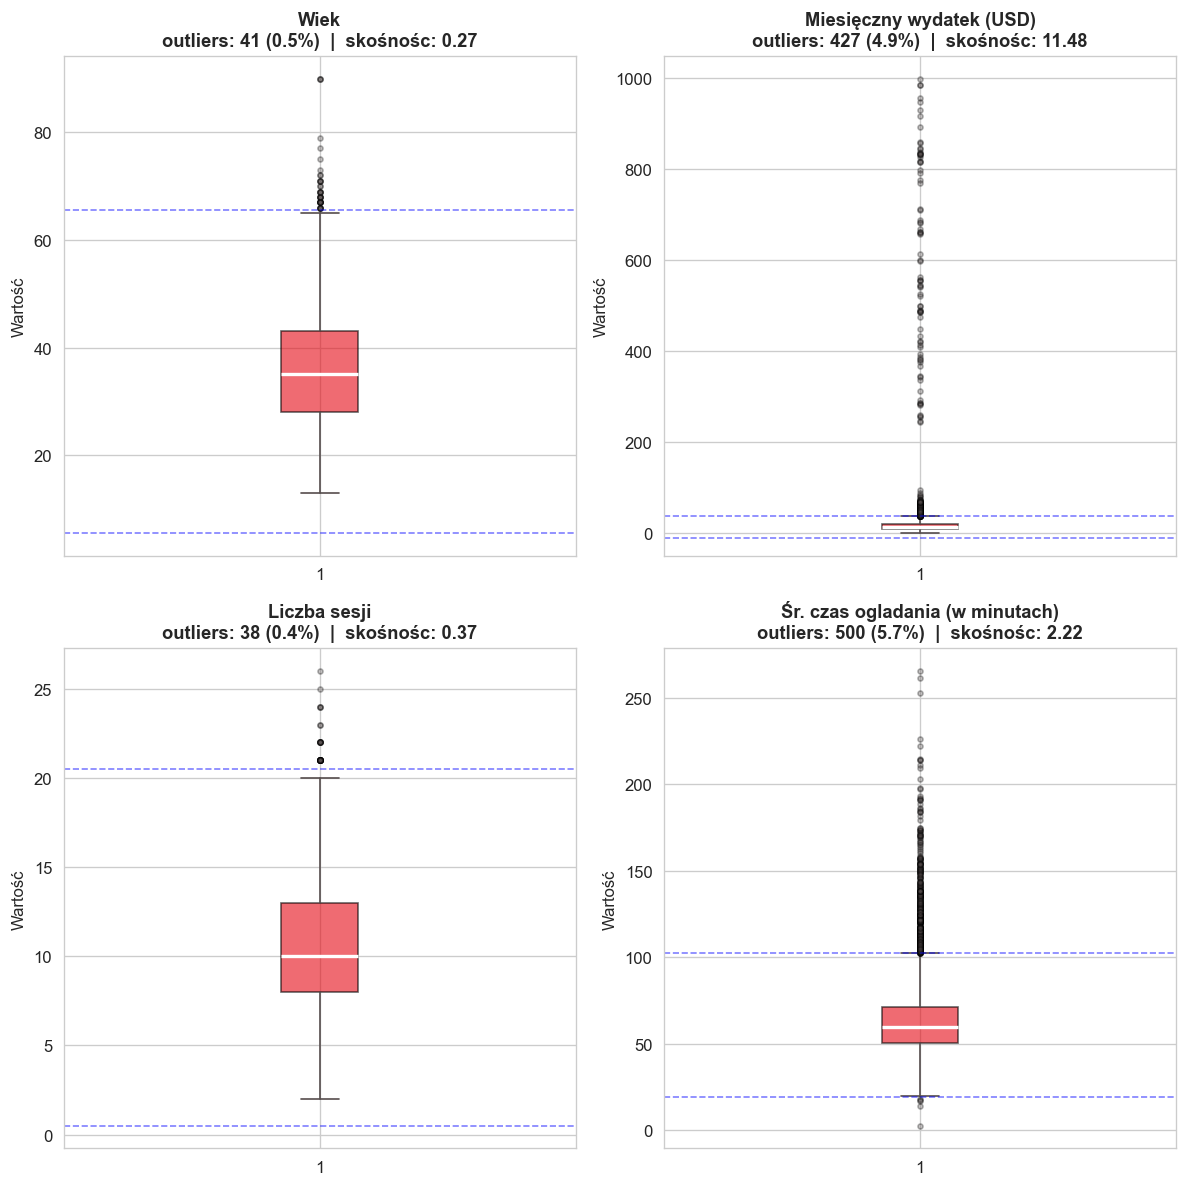

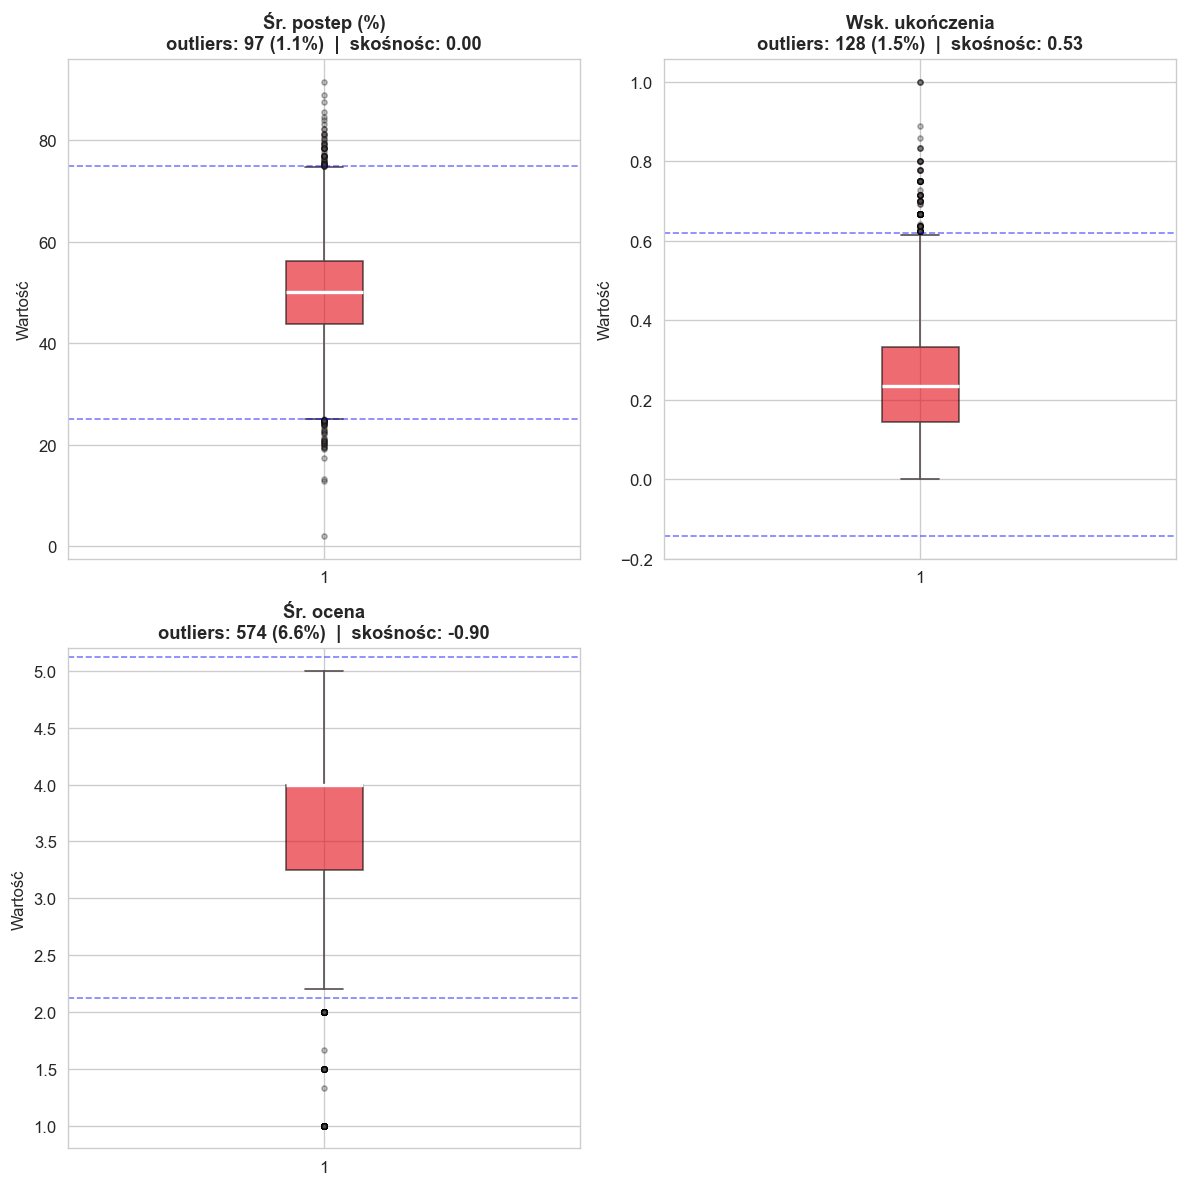

In [6]:
# Tabela (bez zmian)
continuous_cols = ['age','monthly_spend','total_sessions','avg_watch_duration',
                   'avg_progress','completed_ratio','avg_rating']
cont_labels     = ['Wiek','Miesięczny wydatek (USD)','Liczba sesji','Śr. czas ogladania (w minutach)',
                   'Śr. postep (%)','Wsk. ukończenia','Śr. ocena']


print(f"{'Zmienna':<22} {'Q1':>7} {'Q3':>7} {'Dolna':>7} {'Gorna':>7} {'Outlierow':>10} {'%':>6} {'Skosnosc':>10}")
print('-' * 82)

outlier_data = []
for col, label in zip(continuous_cols, cont_labels):
    Q1    = user_profiles[col].quantile(0.25)
    Q3    = user_profiles[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((user_profiles[col] < lower) | (user_profiles[col] > upper)).sum()
    pct   = n_out / len(user_profiles) * 100
    skew  = stats.skew(user_profiles[col].dropna())
    outlier_data.append((col, label, Q1, Q3, lower, upper, n_out, pct, skew))
    print(f"{label:<22} {Q1:>7.2f} {Q3:>7.2f} {lower:>7.2f} {upper:>7.2f} {n_out:>10} {pct:>6.2f}% {skew:>10.2f}")

# Wykres 1 — pierwsze 4 zmienne (2x2)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, (col, label, Q1, Q3, lower, upper, n_out, pct, skew) in enumerate(outlier_data[:4]):
    axes[i].boxplot(user_profiles[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#E50914', alpha=0.6),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#564d4d'),
                    capprops=dict(color='#564d4d'),
                    flierprops=dict(marker='o', markerfacecolor='#564d4d',
                                   markersize=3, alpha=0.3))
    axes[i].set_title(f'{label}\noutliers: {n_out} ({pct:.1f}%)  |  skośnośc: {skew:.2f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Wartość', fontsize=10)
    axes[i].axhline(y=lower, color='blue', linestyle='--', alpha=0.5, linewidth=1)
    axes[i].axhline(y=upper, color='blue', linestyle='--', alpha=0.5, linewidth=1)


plt.tight_layout()
plt.savefig('wykres_boxploty_1.png', bbox_inches='tight')
plt.show()

# Wykres 2 — pozostałe 3 zmienne (2x2 z jedną pustą)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, (col, label, Q1, Q3, lower, upper, n_out, pct, skew) in enumerate(outlier_data[4:]):
    axes[i].boxplot(user_profiles[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#E50914', alpha=0.6),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#564d4d'),
                    capprops=dict(color='#564d4d'),
                    flierprops=dict(marker='o', markerfacecolor='#564d4d',
                                   markersize=3, alpha=0.3))
    axes[i].set_title(f'{label}\noutliers: {n_out} ({pct:.1f}%)  |  skośnośc: {skew:.2f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Wartość', fontsize=10)
    axes[i].axhline(y=lower, color='blue', linestyle='--', alpha=0.5, linewidth=1)
    axes[i].axhline(y=upper, color='blue', linestyle='--', alpha=0.5, linewidth=1)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('wykres_boxploty_2.png', bbox_inches='tight')
plt.show()

### 4.3 Transformacja logarytmiczna zmiennych silnie skosnych

Stosujemy log1p dla zmiennych ciagłych ze skosnoscia |s| > 1.0:
- `monthly_spend` (skosnosc = 11.48)
- `avg_watch_duration` (skosnosc = 2.22)

Zmiennych kategorycznych i dyskretnych nie transformujemy.

Skosność przed transformacją:
  monthly_spend:      11.48
  avg_watch_duration: 2.22
Skosność po transformacji log1p:
  monthly_spend_log:      0.71
  avg_watch_duration_log: 0.51


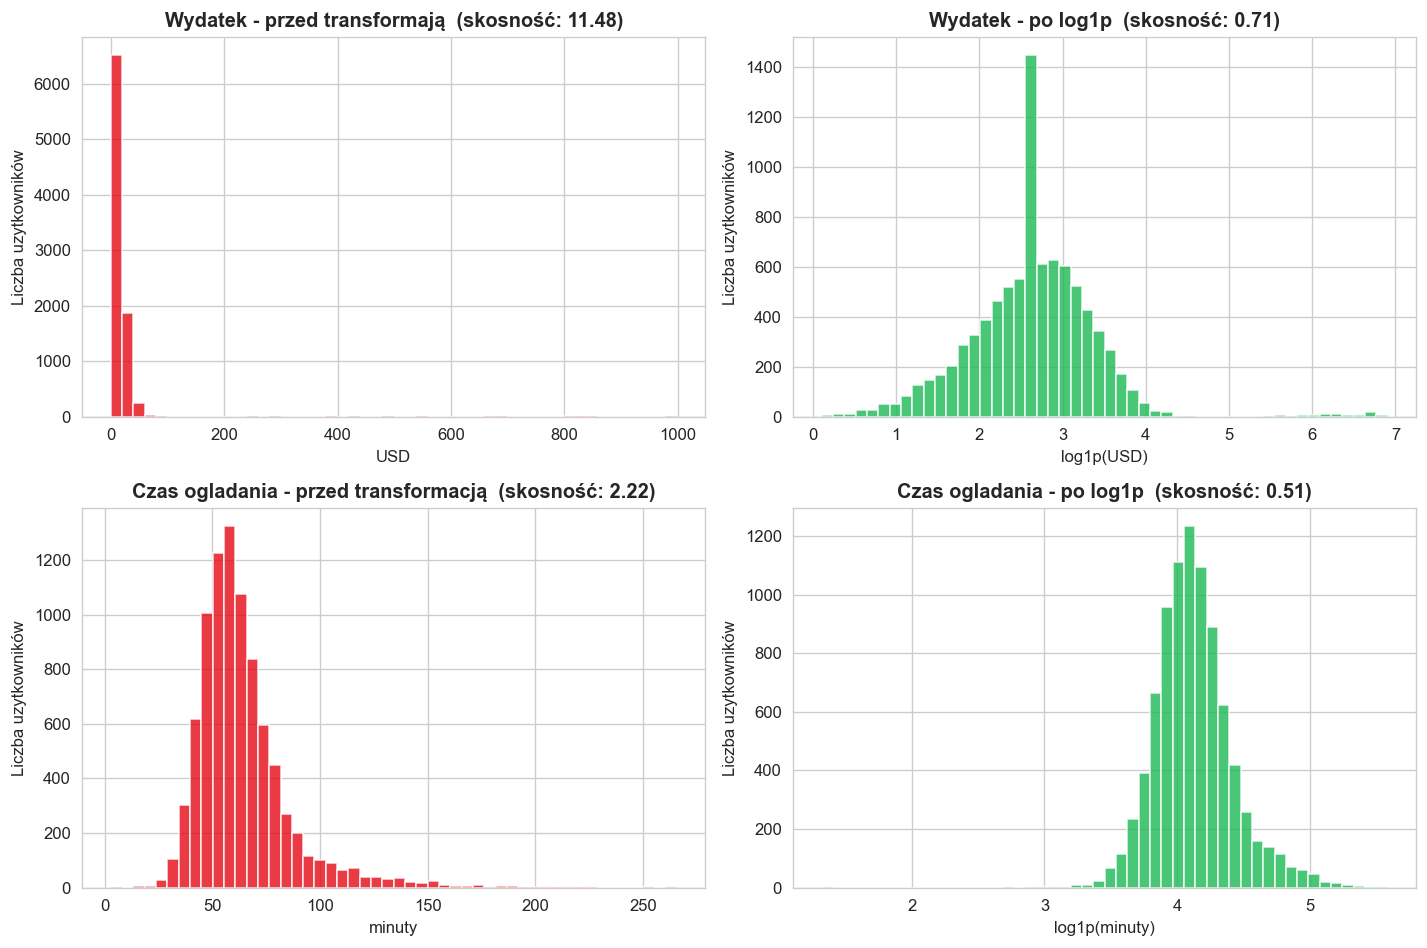

Skosność po transformacji log1p:
  monthly_spend:      11.48  ->  monthly_spend_log:       0.71
  avg_watch_duration: 2.22  ->  avg_watch_duration_log:  0.51


In [7]:
# Transformacja logarytmiczna zmiennych silnie skosnych
user_profiles['monthly_spend_log']      = np.log1p(user_profiles['monthly_spend'])
user_profiles['avg_watch_duration_log'] = np.log1p(user_profiles['avg_watch_duration'])

print('Skosność przed transformacją:')
print(f'  monthly_spend:      {stats.skew(user_profiles["monthly_spend"]):.2f}')
print(f'  avg_watch_duration: {stats.skew(user_profiles["avg_watch_duration"]):.2f}')
print('Skosność po transformacji log1p:')
print(f'  monthly_spend_log:      {stats.skew(user_profiles["monthly_spend_log"]):.2f}')
print(f'  avg_watch_duration_log: {stats.skew(user_profiles["avg_watch_duration_log"]):.2f}')
# Weryfikacja transformacji log1p - porownanie rozkładow przed i po
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(user_profiles['monthly_spend'], bins=50, color='#E50914', edgecolor='white', alpha=0.8)
axes[0,0].set_title(f'Wydatek - przed transformają  (skosność: {stats.skew(user_profiles["monthly_spend"]):.2f})', fontweight='bold')
axes[0,0].set_xlabel('USD')
axes[0,0].set_ylabel('Liczba uzytkowników')

axes[0,1].hist(user_profiles['monthly_spend_log'], bins=50, color='#1DB954', edgecolor='white', alpha=0.8)
axes[0,1].set_title(f'Wydatek - po log1p  (skosność: {stats.skew(user_profiles["monthly_spend_log"]):.2f})', fontweight='bold')
axes[0,1].set_xlabel('log1p(USD)')
axes[0,1].set_ylabel('Liczba uzytkowników')

axes[1,0].hist(user_profiles['avg_watch_duration'], bins=50, color='#E50914', edgecolor='white', alpha=0.8)
axes[1,0].set_title(f'Czas ogladania - przed transformacją  (skosność: {stats.skew(user_profiles["avg_watch_duration"]):.2f})', fontweight='bold')
axes[1,0].set_xlabel('minuty')
axes[1,0].set_ylabel('Liczba uzytkowników')

axes[1,1].hist(user_profiles['avg_watch_duration_log'], bins=50, color='#1DB954', edgecolor='white', alpha=0.8)
axes[1,1].set_title(f'Czas ogladania - po log1p  (skosność: {stats.skew(user_profiles["avg_watch_duration_log"]):.2f})', fontweight='bold')
axes[1,1].set_xlabel('log1p(minuty)')
axes[1,1].set_ylabel('Liczba uzytkowników')


plt.tight_layout()
plt.savefig('wykres_transformacja_log.png', bbox_inches='tight')
plt.show()

print('Skosność po transformacji log1p:')
print(f'  monthly_spend:      {stats.skew(user_profiles["monthly_spend"]):.2f}  ->  monthly_spend_log:       {stats.skew(user_profiles["monthly_spend_log"]):.2f}')
print(f'  avg_watch_duration: {stats.skew(user_profiles["avg_watch_duration"]):.2f}  ->  avg_watch_duration_log:  {stats.skew(user_profiles["avg_watch_duration_log"]):.2f}')


### 4.4 Finalna lista cech i skalowanie

- **Zmienne ciagłe** -> StandardScaler (srednia=0, odch.std=1)
- **Zmienne kategoryczne** -> MinMaxScaler (zakres 0-1)
- `unique_movies_watched` wykluczone ze wzgledu na korelacje r=0.98 z `total_sessions`

In [8]:
continuous_features  = ['age', 'monthly_spend_log', 'total_sessions',
                         'avg_watch_duration_log', 'avg_progress',
                         'completed_ratio', 'avg_rating']
categorical_features = ['plan_enc', 'gender_enc', 'household_size']
cluster_features     = continuous_features + categorical_features

X_cont = user_profiles[continuous_features].values
X_cat  = user_profiles[categorical_features].values

scaler_cont   = StandardScaler()
scaler_cat    = MinMaxScaler()
X_cont_scaled = scaler_cont.fit_transform(X_cont)
X_cat_scaled  = scaler_cat.fit_transform(X_cat)
X_scaled      = np.hstack([X_cont_scaled, X_cat_scaled])

print(f'Macierz cech do klastrowania: {X_scaled.shape}')
print(f'  Ciagłe (StandardScaler):     {len(continuous_features)}')
for f in continuous_features:
    print(f'    - {f}')
print(f'  Kategoryczne (MinMaxScaler): {len(categorical_features)}')
for f in categorical_features:
    print(f'    - {f}')

Macierz cech do klastrowania: (8751, 10)
  Ciagłe (StandardScaler):     7
    - age
    - monthly_spend_log
    - total_sessions
    - avg_watch_duration_log
    - avg_progress
    - completed_ratio
    - avg_rating
  Kategoryczne (MinMaxScaler): 3
    - plan_enc
    - gender_enc
    - household_size


## 5. Grupowanie uzytkownikow — K-means

### 5.1 Metoda lokcia — dobor optymalnej liczby klastrow

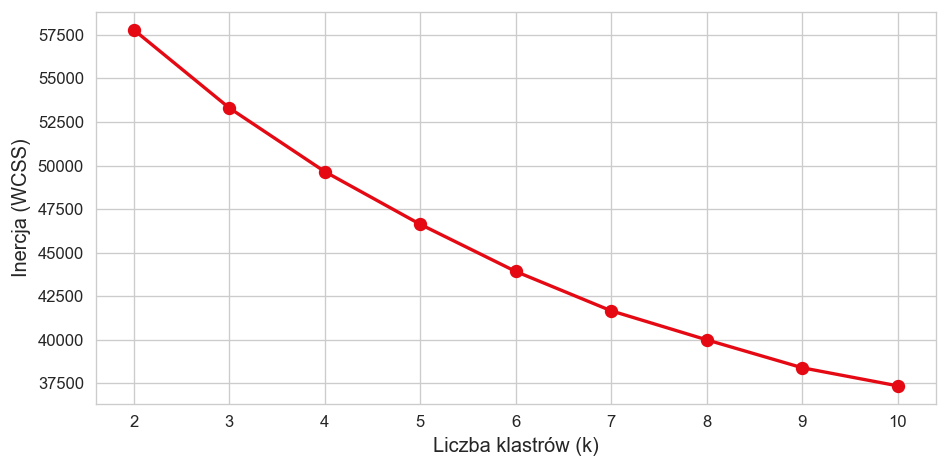

In [9]:
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color='#E50914', linewidth=2, markersize=7)
ax.set_xlabel('Liczba klastrów (k)', fontsize=12)
ax.set_ylabel('Inercja (WCSS)', fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('wykres_elbow.png', bbox_inches='tight')
plt.show()

### 5.2 Klastrowanie z optymalną liczba k

In [10]:
K_OPTIMAL = 4
colors    = ['#E50914','#1DB954','#0063e5','#f5a623']

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
user_profiles['cluster'] = kmeans.fit_predict(X_scaled)

print('Liczba uzytkownikow w kazdym klastrze:')
for c, n in user_profiles['cluster'].value_counts().sort_index().items():
    print(f'  Klaster {c}: {n:,} uzytkownikow')

Liczba uzytkownikow w kazdym klastrze:
  Klaster 0: 2,110 uzytkownikow
  Klaster 1: 1,609 uzytkownikow
  Klaster 2: 2,359 uzytkownikow
  Klaster 3: 2,673 uzytkownikow


### 5.3 Wizualizacja klastrow — PCA 2D

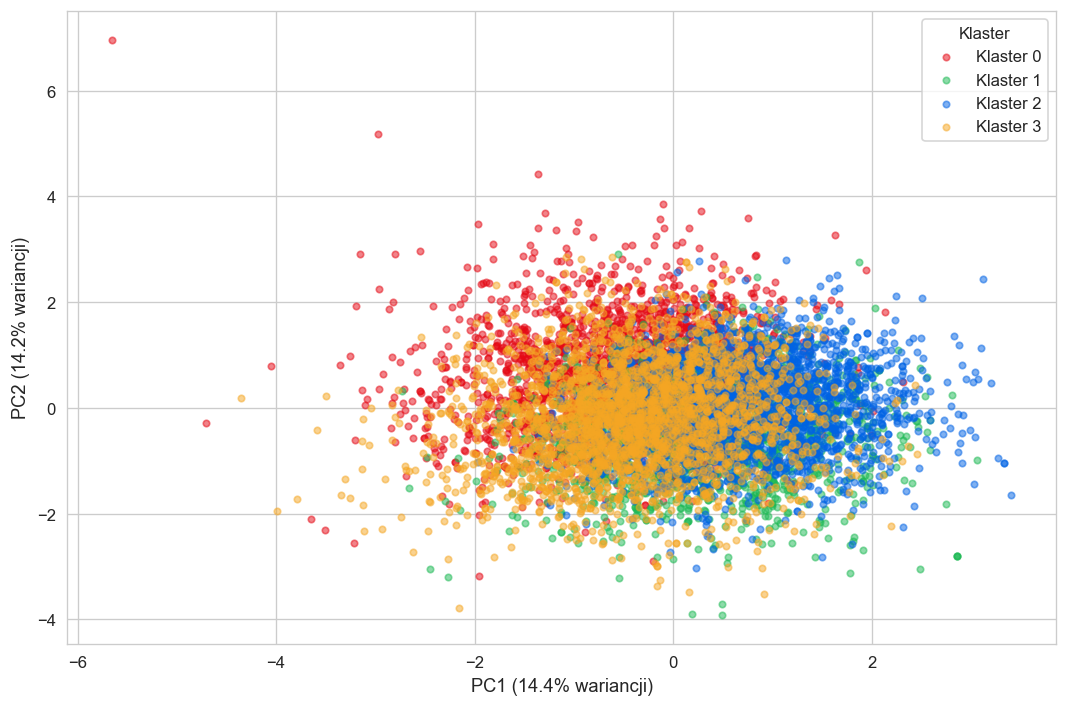

In [11]:



pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df            = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['cluster'] = user_profiles['cluster'].values

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K_OPTIMAL):
    mask = pca_df['cluster'] == c
    ax.scatter(pca_df.loc[mask,'PC1'], pca_df.loc[mask,'PC2'],
               s=15, alpha=0.5, color=colors[c], label=f'Klaster {c}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% wariancji)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% wariancji)', fontsize=11)
ax.legend(title='Klaster', fontsize=10)
plt.tight_layout()
plt.savefig('wykres_pca_klastry.png', bbox_inches='tight')
plt.show()

In [12]:
# Ile wariancji wyjaśniają kolejne komponenty PCA
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

print('Wariancja wyjaśniana przez kolejne komponenty PCA:')
for i, v in enumerate(cumvar):
    print(f'PC1-PC{i+1}: {v:.1f}%')

print()

# Sprawdzenie czy osiągnięto 80%
if np.any(cumvar >= 80):
    n_80 = np.argmax(cumvar >= 80) + 1
    print(f'Liczba komponentów potrzebnych do wyjaśnienia 80% wariancji: {n_80}')
else:
    print(f'80% wariancji nie zostało osiągnięte. Maksymalnie wyjaśniono {cumvar[-1]:.1f}%')

Wariancja wyjaśniana przez kolejne komponenty PCA:
PC1-PC1: 14.4%
PC1-PC2: 28.6%

80% wariancji nie zostało osiągnięte. Maksymalnie wyjaśniono 28.6%


### 5.4 Charakterystyka klastrow

In [13]:
cluster_profile = user_profiles.groupby('cluster').agg(
    liczba_uzytkownikow   = ('user_id', 'count'),
    średni_wiek           = ('age', 'mean'),
    średni_wydatek        = ('monthly_spend', 'mean'),
    średnia_liczba_sesji  = ('total_sessions', 'mean'),
    średni_czas_oglądania = ('avg_watch_duration', 'mean'),
    wskaźnik_ukończenia   = ('completed_ratio', 'mean'),
    średnia_ocena         = ('avg_rating', 'mean')
).round(2)

cluster_profile.columns = ['Liczba użytk.', 'Śr. wiek', 'Śr. wydatek (USD)',
                            'Śr. liczba sesji', 'Śr. czas oglądania (min)',
                            'Wsk. ukończenia', 'Śr. ocena']
print('Charakterystyka klastrów użytkowników:')
cluster_profile

Charakterystyka klastrów użytkowników:


,Liczba użytk.,Śr. wiek,Śr. wydatek (USD),Śr. liczba sesji,Śr. czas oglądania (min),Wsk. ukończenia,Śr. ocena
cluster,,,,,,,
0,2110,37.29,29.21,8.86,60.83,0.42,3.96
1,1609,35.13,17.72,10.86,63.86,0.23,2.46
2,2359,35.64,15.75,14.15,65.12,0.24,4.04
3,2673,35.11,20.91,8.33,65.51,0.13,4.04


### 5.5 Wykres radarowy — profil klastrow

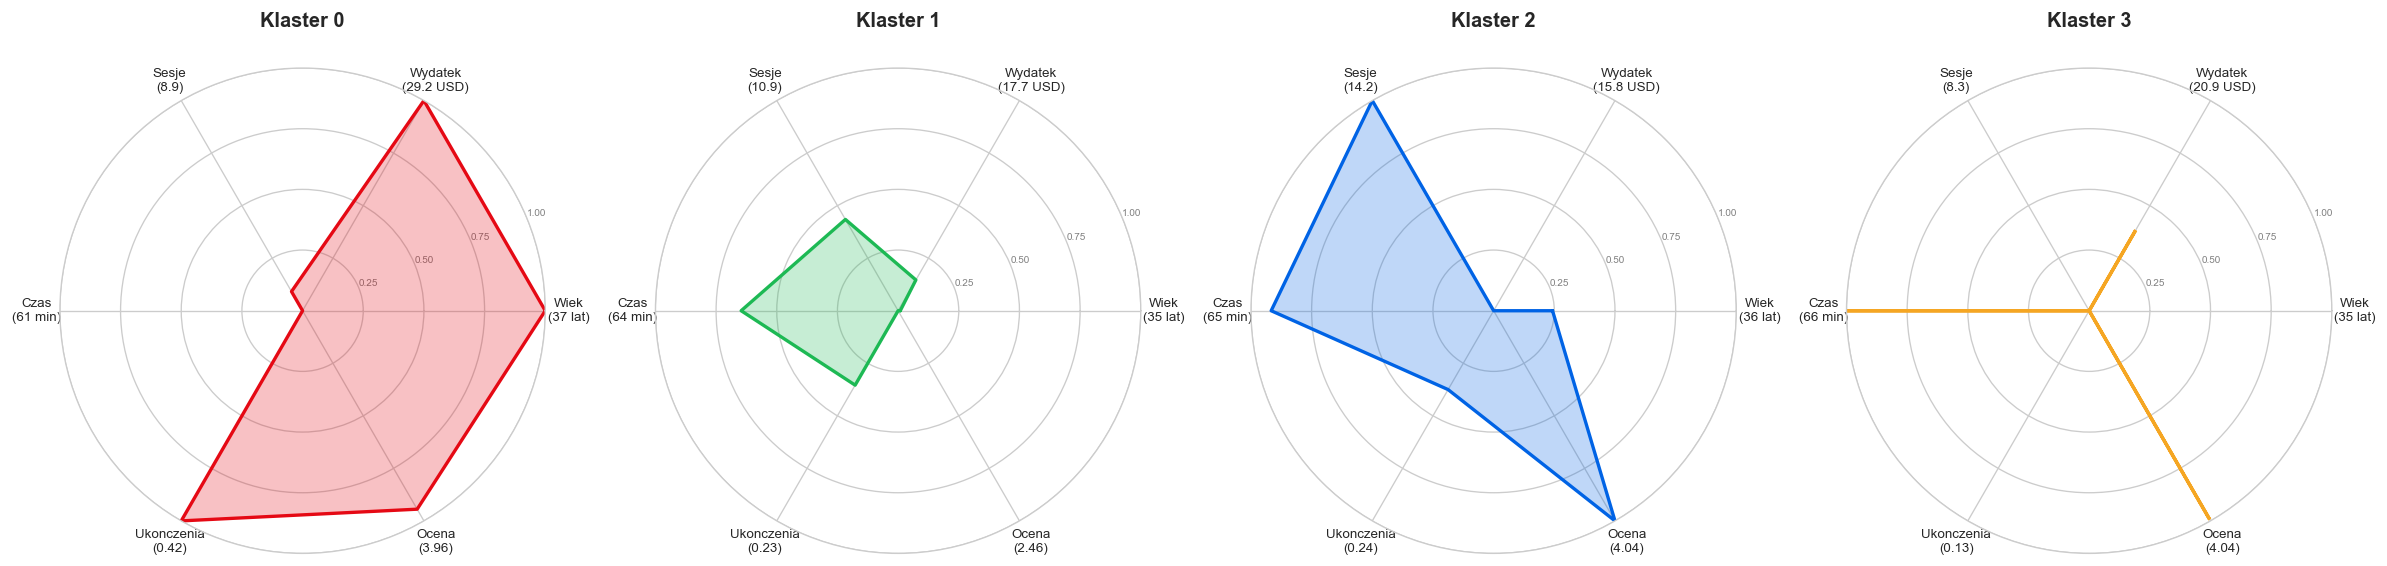

In [14]:
radar_features = ['age','monthly_spend','total_sessions',
                  'avg_watch_duration','completed_ratio','avg_rating']

cluster_means = user_profiles.groupby('cluster')[radar_features].mean()
cluster_norm  = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

N      = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_OPTIMAL, figsize=(5*K_OPTIMAL, 5),
                          subplot_kw=dict(polar=True))
if K_OPTIMAL == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    vals = cluster_norm.iloc[i].tolist() + cluster_norm.iloc[i].tolist()[:1]
    real = cluster_means.iloc[i]

    ax.plot(angles, vals, color=colors[i], linewidth=2)
    ax.fill(angles, vals, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])

    # Etykiety z rzeczywistymi wartościami pod spodem
    labels_with_vals = [
        f'Wiek\n({real["age"]:.0f} lat)',
        f'Wydatek\n({real["monthly_spend"]:.1f} USD)',
        f'Sesje\n({real["total_sessions"]:.1f})',
        f'Czas\n({real["avg_watch_duration"]:.0f} min)',
        f'Ukonczenia\n({real["completed_ratio"]:.2f})',
        f'Ocena\n({real["avg_rating"]:.2f})'
    ]
    ax.set_xticklabels(labels_with_vals, size=8)
    ax.set_title(f'Klaster {i}', size=12, fontweight='bold', pad=25)
    ax.set_ylim(0, 1)

    # Siatka co 0.25
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'], size=6, color='grey')

plt.tight_layout()
plt.savefig('wykres_radar_klastry.png', bbox_inches='tight')
plt.show()

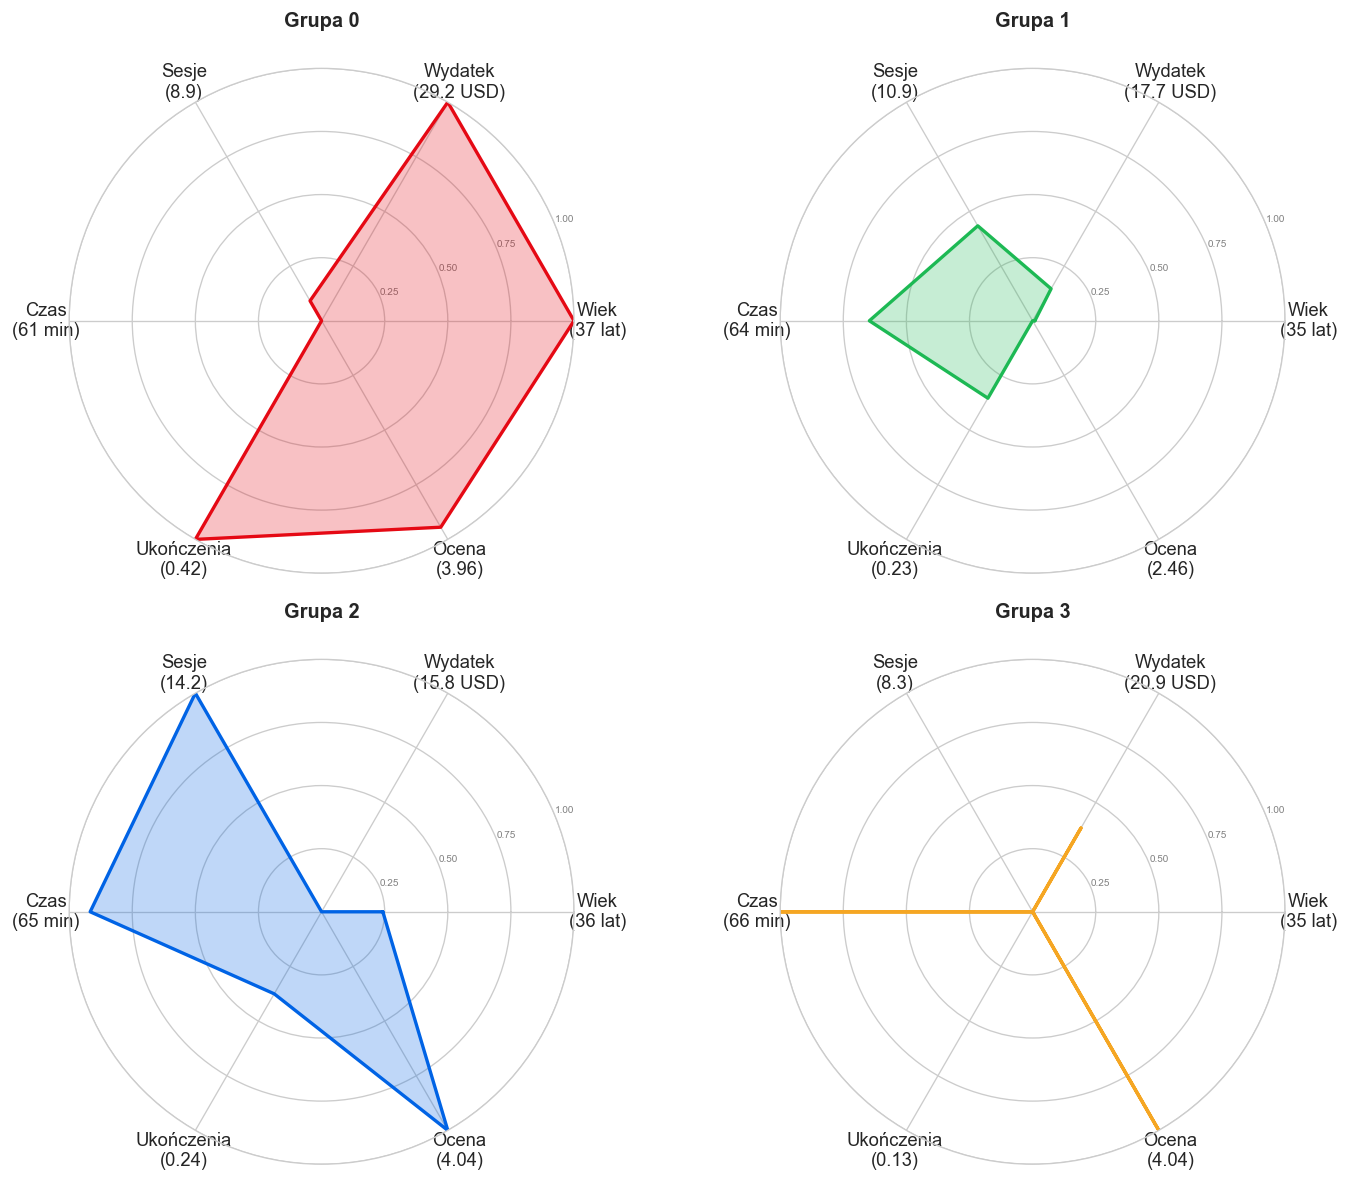

In [22]:
radar_features = ['age','monthly_spend','total_sessions',
                  'avg_watch_duration','completed_ratio','avg_rating']
cluster_means = user_profiles.groupby('cluster')[radar_features].mean()
cluster_norm  = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

N      = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, ax in enumerate(axes):
    vals = cluster_norm.iloc[i].tolist() + cluster_norm.iloc[i].tolist()[:1]
    real = cluster_means.iloc[i]
    ax.plot(angles, vals, color=colors[i], linewidth=2)
    ax.fill(angles, vals, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    labels_with_vals = [
        f'Wiek\n({real["age"]:.0f} lat)',
        f'Wydatek\n({real["monthly_spend"]:.1f} USD)',
        f'Sesje\n({real["total_sessions"]:.1f})',
        f'Czas\n({real["avg_watch_duration"]:.0f} min)',
        f'Ukończenia\n({real["completed_ratio"]:.2f})',
        f'Ocena\n({real["avg_rating"]:.2f})'
    ]
    ax.set_xticklabels(labels_with_vals, size=11)
    ax.set_title(f'Grupa {i}', size=12, fontweight='bold', pad=25)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'], size=6, color='grey')

plt.tight_layout()
plt.savefig('wykres_radar_grupy.png', bbox_inches='tight')
plt.show()

## 6. System rekomendacyjny — filtrowanie kolaboracyjne

Dwa warianty:
- **Bazowy CF** — KNN na wszystkich uzytkownikach
- **CF z klastrami** — KNN tylko w obrebie klastra (Liu Xiaojun, 2017)

In [16]:
ratings = reviews[['user_id','movie_id','rating']].copy()

users_in_ratings  = ratings['user_id'].unique()
movies_in_ratings = ratings['movie_id'].unique()

user2idx  = {u: i for i, u in enumerate(users_in_ratings)}
movie2idx = {m: i for i, m in enumerate(movies_in_ratings)}
idx2movie = {i: m for m, i in movie2idx.items()}

ratings['u_idx'] = ratings['user_id'].map(user2idx)
ratings['m_idx'] = ratings['movie_id'].map(movie2idx)

train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

n_users  = len(users_in_ratings)
n_movies = len(movies_in_ratings)
train_matrix = csr_matrix(
    (train_df['rating'].values, (train_df['u_idx'].values, train_df['m_idx'].values)),
    shape=(n_users, n_movies)
)

gestosc = ratings.shape[0] / (n_users * n_movies) * 100
print(f'Macierz ocen: {n_users} uzytkownikow x {n_movies} filmow')
print(f'Gestosc macierzy: {gestosc:.2f}%')
print(f'Zbior treningowy: {len(train_df):,} ocen')
print(f'Zbior testowy:    {len(test_df):,} ocen')

Macierz ocen: 7761 uzytkownikow x 1000 filmow
Gestosc macierzy: 0.20%
Zbior treningowy: 12,360 ocen
Zbior testowy:    3,090 ocen


### 6.1 Funkcje predykcji

In [17]:
def predict_ratings_knn(test_df, train_matrix, n_neighbors=20, metric='cosine'):
    """Bazowy CF: user-based KNN na wszystkich uzytkownikach."""
    model = NearestNeighbors(n_neighbors=n_neighbors+1, metric=metric, algorithm='brute')
    model.fit(train_matrix)
    preds, actuals = [], []
    for _, row in test_df.iterrows():
        u, m, actual = int(row['u_idx']), int(row['m_idx']), row['rating']
        distances, indices = model.kneighbors(train_matrix[u], n_neighbors=n_neighbors+1)
        neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u]
        ratings_n, sims = [], []
        for n_idx, dist in neighbors:
            r = train_matrix[n_idx, m]
            if r > 0:
                ratings_n.append(r); sims.append(1 - dist)
        if ratings_n and sum(sims) > 0:
            pred = np.average(ratings_n, weights=sims)
        else:
            nz = train_matrix[:, m].data
            pred = nz.mean() if len(nz) > 0 else 3.0
        preds.append(np.clip(pred, 1, 5)); actuals.append(actual)
    return np.array(actuals), np.array(preds)


def predict_ratings_cluster_cf(test_df, train_df_full, user_profiles,
                                user2idx, train_matrix, movie2idx,
                                n_neighbors=20, metric='cosine'):
    """CF z klastrami z fallbackiem do globalnego CF (Liu Xiaojun, 2017)."""
    user_cluster = user_profiles.set_index('user_id')['cluster'].to_dict()
    global_model = NearestNeighbors(n_neighbors=n_neighbors+1, metric=metric, algorithm='brute')
    global_model.fit(train_matrix)

    preds, actuals = [], []
    for _, row in test_df.iterrows():
        u_id, m_id, actual = row['user_id'], row['movie_id'], row['rating']
        u_g = user2idx.get(u_id, -1)
        m_g = movie2idx.get(m_id, -1)
        pred = None

        # Próba predykcji z klastra
        cluster_id    = user_cluster.get(u_id, -1)
        cluster_users = user_profiles[user_profiles['cluster'] == cluster_id]['user_id'].values
        cluster_train = train_df_full[train_df_full['user_id'].isin(cluster_users)]

        if len(cluster_train) > 0 and u_g >= 0:
            c_users  = cluster_train['user_id'].unique()
            c_movies = cluster_train['movie_id'].unique()
            cu2i = {u: i for i, u in enumerate(c_users)}
            cm2i = {m: i for i, m in enumerate(c_movies)}
            if u_id in cu2i and m_id in cm2i:
                cluster_matrix = csr_matrix(
                    (cluster_train['rating'].values,
                     (cluster_train['user_id'].map(cu2i).values,
                      cluster_train['movie_id'].map(cm2i).values)),
                    shape=(len(c_users), len(c_movies))
                )
                u_local, m_local = cu2i[u_id], cm2i[m_id]
                k     = min(n_neighbors + 1, len(c_users))
                model = NearestNeighbors(n_neighbors=k, metric=metric, algorithm='brute')
                model.fit(cluster_matrix)
                distances, indices = model.kneighbors(cluster_matrix[u_local], n_neighbors=k)
                neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_local]
                ratings_n, sims = [], []
                for n_idx, dist in neighbors:
                    r = cluster_matrix[n_idx, m_local]
                    if r > 0:
                        ratings_n.append(r); sims.append(1 - dist)
                if ratings_n and sum(sims) > 0:
                    pred = np.average(ratings_n, weights=sims)

        # Fallback: globalny CF
        if pred is None and u_g >= 0:
            distances, indices = global_model.kneighbors(train_matrix[u_g], n_neighbors=n_neighbors+1)
            neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_g]
            ratings_n, sims = [], []
            for n_idx, dist in neighbors:
                r = train_matrix[n_idx, m_g] if m_g >= 0 else 0
                if r > 0:
                    ratings_n.append(r); sims.append(1 - dist)
            if ratings_n and sum(sims) > 0:
                pred = np.average(ratings_n, weights=sims)

        # Fallback ostateczny: srednia globalna
        if pred is None:
            nz = train_matrix[:, m_g].data if m_g >= 0 else []
            pred = nz.mean() if len(nz) > 0 else (train_matrix.data.mean() if len(train_matrix.data) > 0 else 3.5)

        preds.append(np.clip(pred, 1, 5)); actuals.append(actual)
    return np.array(actuals), np.array(preds)

print('Funkcje predykcji gotowe.')

Funkcje predykcji gotowe.


### 6.2 Ewaluacja dla k w {10, 15, 20, 25, 30, 35} — zgodnie z Lee et al. (2012)

In [18]:
cluster_map = (
    user_profiles[["user_id", "cluster"]]
    .drop_duplicates(subset="user_id")
    .set_index("user_id")["cluster"]
)

test_with_cluster = test_df.copy()
test_with_cluster["cluster"] = test_with_cluster["user_id"].map(cluster_map)
test_with_cluster = test_with_cluster.dropna(subset=["cluster"])

N_EVAL = len(test_with_cluster)
test_sample = test_with_cluster.sample(N_EVAL, random_state=42)
K_VALUES    = [10, 15, 20, 25, 30, 35]
results     = []

print(f"Ewaluacja na {N_EVAL} przykladach testowych...")
print(f"\n{'KN':>4} | {'MAE Bazowy CF':>14} | {'RMSE Bazowy CF':>14} | {'MAE CF+Klastry':>14} | {'RMSE CF+Klastry':>15}")
print("-" * 72)

for k in K_VALUES:
    y_true_b, y_pred_b = predict_ratings_knn(test_sample, train_matrix, n_neighbors=k)
    mae_b  = mean_absolute_error(y_true_b, y_pred_b)
    rmse_b = np.sqrt(mean_squared_error(y_true_b, y_pred_b))

    y_true_c, y_pred_c = predict_ratings_cluster_cf(
        test_sample, train_df, user_profiles, user2idx,
        train_matrix, movie2idx, n_neighbors=k)
    mae_c  = mean_absolute_error(y_true_c, y_pred_c)
    rmse_c = np.sqrt(mean_squared_error(y_true_c, y_pred_c))

    results.append({"KN": k, "MAE_base": mae_b, "RMSE_base": rmse_b,
                    "MAE_cluster": mae_c, "RMSE_cluster": rmse_c})
    print(f"{k:>4} | {mae_b:>14.3f} | {rmse_b:>14.3f} | {mae_c:>14.3f} | {rmse_c:>15.3f}")

results_df = pd.DataFrame(results)

Ewaluacja na 2652 przykladach testowych...

  KN |  MAE Bazowy CF | RMSE Bazowy CF | MAE CF+Klastry | RMSE CF+Klastry
------------------------------------------------------------------------
  10 |          0.958 |          1.183 |          0.954 |           1.179
  15 |          0.958 |          1.184 |          0.955 |           1.182
  20 |          0.959 |          1.185 |          0.956 |           1.183
  25 |          0.959 |          1.185 |          0.956 |           1.183
  30 |          0.960 |          1.186 |          0.957 |           1.184


KeyboardInterrupt: 

In [ ]:
def predict_ratings_knn(test_df, train_matrix, n_neighbors=20, metric='cosine'):
    """Bazowy CF: user-based KNN na wszystkich uzytkownikach."""
    model = NearestNeighbors(n_neighbors=n_neighbors+1, metric=metric, algorithm='brute')
    model.fit(train_matrix)
    preds, actuals = [], []
    for _, row in test_df.iterrows():
        u, m, actual = int(row['u_idx']), int(row['m_idx']), row['rating']
        distances, indices = model.kneighbors(train_matrix[u], n_neighbors=n_neighbors+1)
        neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u]
        ratings_n, sims = [], []
        for n_idx, dist in neighbors:
            r = train_matrix[n_idx, m]
            if r > 0:
                ratings_n.append(r); sims.append(1 - dist)
        if ratings_n and sum(sims) > 0:
            pred = np.average(ratings_n, weights=sims)
        else:
            nz = train_matrix[:, m].data
            pred = nz.mean() if len(nz) > 0 else 3.0
        preds.append(np.clip(pred, 1, 5)); actuals.append(actual)
    return np.array(actuals), np.array(preds)


def predict_ratings_cluster_cf(test_df, train_df_full, user_profiles,
                                user2idx, train_matrix, movie2idx,
                                n_neighbors=20, metric='cosine'):
    """CF z klastrami z fallbackiem do globalnego CF (Liu Xiaojun, 2017)."""
    user_cluster = user_profiles.set_index('user_id')['cluster'].to_dict()
    global_model = NearestNeighbors(n_neighbors=n_neighbors+1, metric=metric, algorithm='brute')
    global_model.fit(train_matrix)

    preds, actuals = [], []
    for _, row in test_df.iterrows():
        u_id, m_id, actual = row['user_id'], row['movie_id'], row['rating']
        u_g = user2idx.get(u_id, -1)
        m_g = movie2idx.get(m_id, -1)
        pred = None

        # Próba predykcji z klastra
        cluster_id    = user_cluster.get(u_id, -1)
        cluster_users = user_profiles[user_profiles['cluster'] == cluster_id]['user_id'].values
        cluster_train = train_df_full[train_df_full['user_id'].isin(cluster_users)]

        if len(cluster_train) > 0 and u_g >= 0:
            c_users  = cluster_train['user_id'].unique()
            c_movies = cluster_train['movie_id'].unique()
            cu2i = {u: i for i, u in enumerate(c_users)}
            cm2i = {m: i for i, m in enumerate(c_movies)}
            if u_id in cu2i and m_id in cm2i:
                cluster_matrix = csr_matrix(
                    (cluster_train['rating'].values,
                     (cluster_train['user_id'].map(cu2i).values,
                      cluster_train['movie_id'].map(cm2i).values)),
                    shape=(len(c_users), len(c_movies))
                )
                u_local, m_local = cu2i[u_id], cm2i[m_id]
                k     = min(n_neighbors + 1, len(c_users))
                model = NearestNeighbors(n_neighbors=k, metric=metric, algorithm='brute')
                model.fit(cluster_matrix)
                distances, indices = model.kneighbors(cluster_matrix[u_local], n_neighbors=k)
                neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_local]
                ratings_n, sims = [], []
                for n_idx, dist in neighbors:
                    r = cluster_matrix[n_idx, m_local]
                    if r > 0:
                        ratings_n.append(r); sims.append(1 - dist)
                if ratings_n and sum(sims) > 0:
                    pred = np.average(ratings_n, weights=sims)

        # Fallback: globalny CF
        if pred is None and u_g >= 0:
            distances, indices = global_model.kneighbors(train_matrix[u_g], n_neighbors=n_neighbors+1)
            neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_g]
            ratings_n, sims = [], []
            for n_idx, dist in neighbors:
                r = train_matrix[n_idx, m_g] if m_g >= 0 else 0
                if r > 0:
                    ratings_n.append(r); sims.append(1 - dist)
            if ratings_n and sum(sims) > 0:
                pred = np.average(ratings_n, weights=sims)

        # Fallback ostateczny: srednia globalna
        if pred is None:
            nz = train_matrix[:, m_g].data if m_g >= 0 else []
            pred = nz.mean() if len(nz) > 0 else (train_matrix.data.mean() if len(train_matrix.data) > 0 else 3.5)

        preds.append(np.clip(pred, 1, 5)); actuals.append(actual)
    return np.array(actuals), np.array(preds)

print('Funkcje predykcji gotowe.')

Funkcje predykcji gotowe.


### 6.3 Tabela porowawcza wynikow

In [ ]:
results_df['Lepszy_MAE'] = results_df.apply(
    lambda r: 'CF+Klastry' if r['MAE_cluster'] < r['MAE_base'] else 'Bazowy CF', axis=1)

display_df = results_df.copy()
display_df.columns = ['Liczba sasiadow KN','MAE Bazowy CF','RMSE Bazowy CF',
                       'MAE CF+Klastry','RMSE CF+Klastry','Lepszy (MAE)']
display_df = display_df.round(3)

avg_row = display_df[['MAE Bazowy CF','RMSE Bazowy CF',
                       'MAE CF+Klastry','RMSE CF+Klastry']].mean().round(3)
avg_row['Liczba sasiadow KN'] = 'Srednia'
avg_row['Lepszy (MAE)'] = 'CF+Klastry' if avg_row['MAE CF+Klastry'] < avg_row['MAE Bazowy CF'] else 'Bazowy CF'
display_df = pd.concat([display_df, pd.DataFrame([avg_row])], ignore_index=True)

print('Tabela 1. Porownanie MAE i RMSE algorytmow rekomendacyjnych')
display_df

Tabela 1. Porownanie MAE i RMSE algorytmow rekomendacyjnych


,Liczba sasiadow KN,MAE Bazowy CF,RMSE Bazowy CF,MAE CF+Klastry,RMSE CF+Klastry,Lepszy (MAE)
0,10,0.958,1.183,0.954,1.179,CF+Klastry
1,15,0.958,1.184,0.955,1.182,CF+Klastry
2,20,0.959,1.185,0.956,1.183,CF+Klastry
3,25,0.959,1.185,0.956,1.183,CF+Klastry
4,30,0.960,1.186,0.957,1.184,CF+Klastry
5,35,0.960,1.187,0.957,1.184,CF+Klastry
6,Srednia,0.959,1.185,0.956,1.182,CF+Klastry


### 6.4 Wykres porownawczy MAE i RMSE

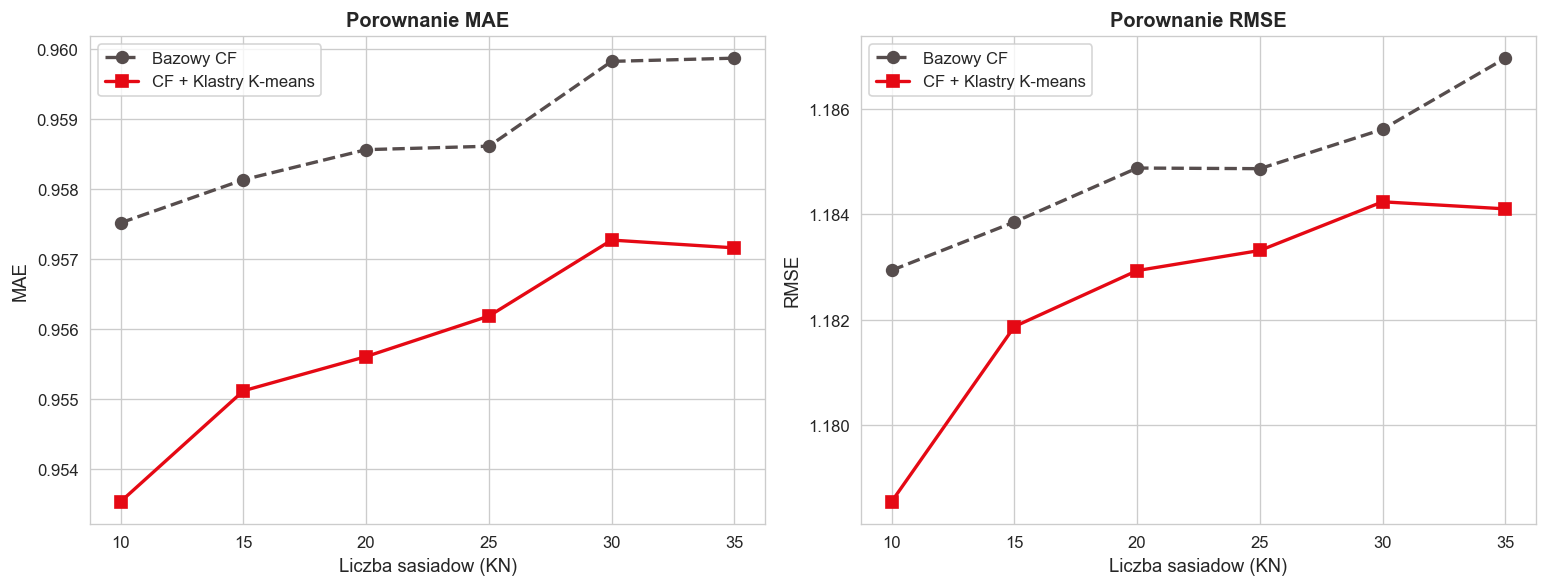

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
k_vals = results_df['KN'].values

for ax, metric, title in zip(axes, ['MAE','RMSE'], ['Porownanie MAE','Porownanie RMSE']):
    ax.plot(k_vals, results_df[f'{metric}_base'],    'o--', color='#564d4d',
            linewidth=2, markersize=7, label='Bazowy CF')
    ax.plot(k_vals, results_df[f'{metric}_cluster'], 's-',  color='#E50914',
            linewidth=2, markersize=7, label='CF + Klastry K-means')
    ax.set_xlabel('Liczba sasiadow (KN)', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('wykres_mae_rmse.png', bbox_inches='tight')
plt.show()

## 7. Przykladowe rekomendacje Top-10

In [ ]:
def recommend_for_user(user_id, train_df, user_profiles, movies,
                        user2idx, n_neighbors=20, top_n=10):
    """Generuje Top-N rekomendacji metoda CF z klastrami."""
    cluster_id    = user_profiles.set_index('user_id')['cluster'].get(user_id, -1)
    cluster_users = user_profiles[user_profiles['cluster'] == cluster_id]['user_id'].values
    cluster_train = train_df[train_df['user_id'].isin(cluster_users)]
    c_users  = cluster_train['user_id'].unique()
    c_movies = cluster_train['movie_id'].unique()
    if user_id not in c_users:
        print('Brak ocen treningowych w klastrze.')
        return None
    cu2i = {u: i for i, u in enumerate(c_users)}
    cm2i = {m: i for i, m in enumerate(c_movies)}
    ci2m = {i: m for m, i in cm2i.items()}
    cluster_matrix = csr_matrix(
        (cluster_train['rating'].values,
         (cluster_train['user_id'].map(cu2i).values,
          cluster_train['movie_id'].map(cm2i).values)),
        shape=(len(c_users), len(c_movies))
    )
    u_local = cu2i[user_id]
    k       = min(n_neighbors + 1, len(c_users))
    model   = NearestNeighbors(n_neighbors=k, metric='cosine', algorithm='brute')
    model.fit(cluster_matrix)
    distances, indices = model.kneighbors(cluster_matrix[u_local], n_neighbors=k)
    neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_local]
    seen      = set(train_df[train_df['user_id'] == user_id]['movie_id'].values)
    scores    = {}
    for m_local in range(len(c_movies)):
        m_id = ci2m[m_local]
        if m_id in seen:
            continue
        ratings_n, sims = [], []
        for n_idx, dist in neighbors:
            r = cluster_matrix[n_idx, m_local]
            if r > 0:
                ratings_n.append(r); sims.append(1 - dist)
        if ratings_n and sum(sims) > 0:
            scores[m_id] = np.average(ratings_n, weights=sims)
    top_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    recs = pd.DataFrame(top_movies, columns=['movie_id','predicted_rating'])
    recs = recs.merge(movies[['movie_id','title','genre_primary','imdb_rating',
                               'content_type']], on='movie_id', how='left')
    recs['predicted_rating'] = recs['predicted_rating'].round(2)
    recs.index = range(1, len(recs)+1)
    return recs

example_user = reviews['user_id'].sample(1, random_state=7).values[0]
u_cluster    = user_profiles.set_index('user_id')['cluster'].get(example_user, '?')
print(f'Rekomendacje dla: {example_user}  (Klaster {u_cluster})')
recs = recommend_for_user(example_user, train_df, user_profiles, movies,
                           user2idx, n_neighbors=20, top_n=10)
if recs is not None:
    recs[['title','genre_primary','content_type','imdb_rating','predicted_rating']]

Rekomendacje dla: user_07228  (Klaster 1)


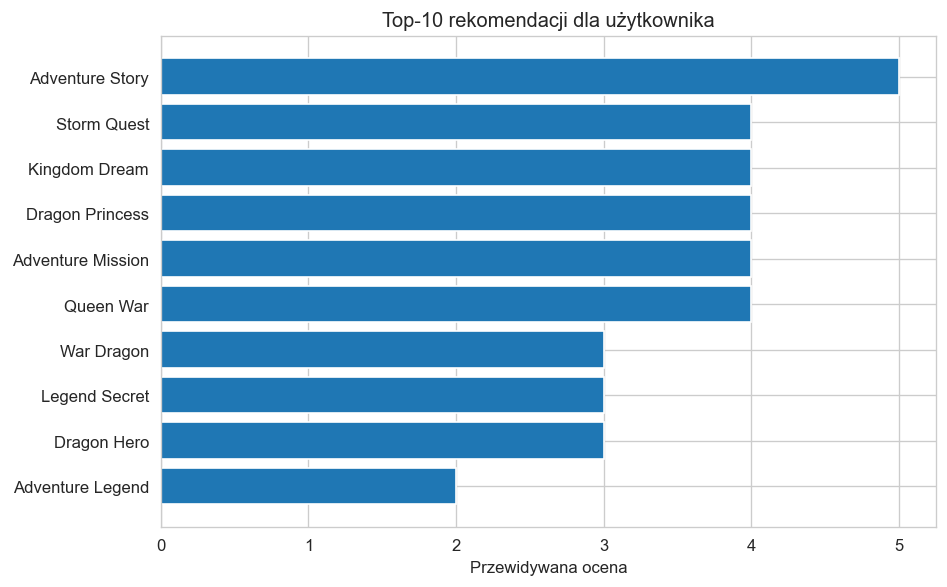

In [ ]:
recs_plot = recs.sort_values('predicted_rating')

plt.figure(figsize=(8,5))
plt.barh(recs_plot['title'], recs_plot['predicted_rating'])
plt.xlabel('Przewidywana ocena')
plt.title('Top-10 rekomendacji dla użytkownika')
plt.tight_layout()
plt.show()

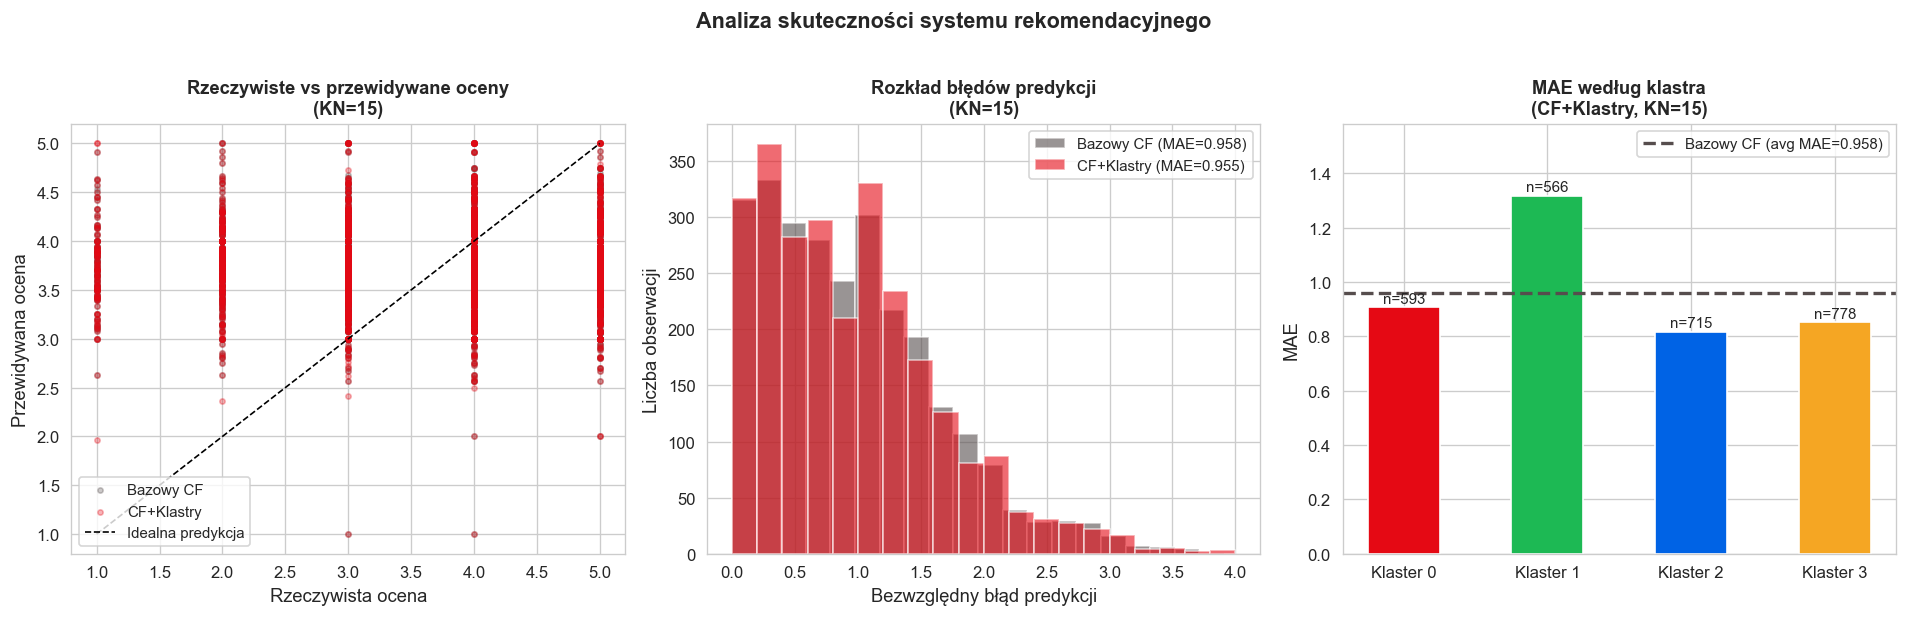

In [ ]:
# Wizualizacja: jak podobni są sąsiedzi w klastrze vs globalnie
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Wykres 1: Rozkład przewidywanych ocen vs rzeczywistych ---
axes[0].hist(test_sample['rating'], bins=10, alpha=0.6, 
             color='#564d4d', label='Rzeczywiste oceny', edgecolor='white')
axes[0].hist(results_df['MAE_cluster'].values, bins=5, alpha=0.6,
             color='#E50914', label='MAE CF+Klastry', edgecolor='white')
# Lepiej: scatter rzeczywiste vs przewidywane
y_true_best, y_pred_best = predict_ratings_cluster_cf(
    test_sample, train_df, user_profiles, user2idx,
    train_matrix, movie2idx, n_neighbors=15)
y_true_base, y_pred_base = predict_ratings_knn(
    test_sample, train_matrix, n_neighbors=15)

axes[0].clear()
axes[0].scatter(y_true_base, y_pred_base, alpha=0.3, s=10, 
                color='#564d4d', label='Bazowy CF')
axes[0].scatter(y_true_best, y_pred_best, alpha=0.3, s=10,
                color='#E50914', label='CF+Klastry')
axes[0].plot([1,5],[1,5], 'k--', linewidth=1, label='Idealna predykcja')
axes[0].set_xlabel('Rzeczywista ocena', fontsize=11)
axes[0].set_ylabel('Przewidywana ocena', fontsize=11)
axes[0].set_title('Rzeczywiste vs przewidywane oceny\n(KN=15)', 
                   fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# --- Wykres 2: Rozkład błędów predykcji ---
errors_base    = np.abs(y_true_base - y_pred_base)
errors_cluster = np.abs(y_true_best - y_pred_best)

axes[1].hist(errors_base, bins=20, alpha=0.6, color='#564d4d',
             label=f'Bazowy CF (MAE={errors_base.mean():.3f})', edgecolor='white')
axes[1].hist(errors_cluster, bins=20, alpha=0.6, color='#E50914',
             label=f'CF+Klastry (MAE={errors_cluster.mean():.3f})', edgecolor='white')
axes[1].set_xlabel('Bezwzględny błąd predykcji', fontsize=11)
axes[1].set_ylabel('Liczba obserwacji', fontsize=11)
axes[1].set_title('Rozkład błędów predykcji\n(KN=15)', 
                   fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

# --- Wykres 3: MAE według klastra ---
mae_per_cluster = []
for c in range(K_OPTIMAL):
    test_c = test_sample[test_sample['cluster'] == c]
    if len(test_c) > 0:
        yt, yp = predict_ratings_cluster_cf(
            test_c, train_df, user_profiles, user2idx,
            train_matrix, movie2idx, n_neighbors=15)
        mae_per_cluster.append({
            'Klaster': f'Klaster {c}',
            'MAE': mean_absolute_error(yt, yp),
            'n': len(test_c)
        })

mae_df = pd.DataFrame(mae_per_cluster)
bars = axes[2].bar(mae_df['Klaster'], mae_df['MAE'],
                    color=['#E50914','#1DB954','#0063e5','#f5a623'],
                    edgecolor='white', width=0.5)
axes[2].axhline(y=errors_base.mean(), color='#564d4d', linestyle='--',
                linewidth=2, label=f'Bazowy CF (avg MAE={errors_base.mean():.3f})')
for bar, row in zip(bars, mae_df.itertuples()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'n={row.n}', ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('MAE', fontsize=11)
axes[2].set_title('MAE według klastra\n(CF+Klastry, KN=15)', 
                   fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, max(mae_df['MAE'].max(), errors_base.mean()) * 1.2)

plt.suptitle('Analiza skuteczności systemu rekomendacyjnego', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wykres_analiza_skutecznosci.png', bbox_inches='tight')
plt.show()

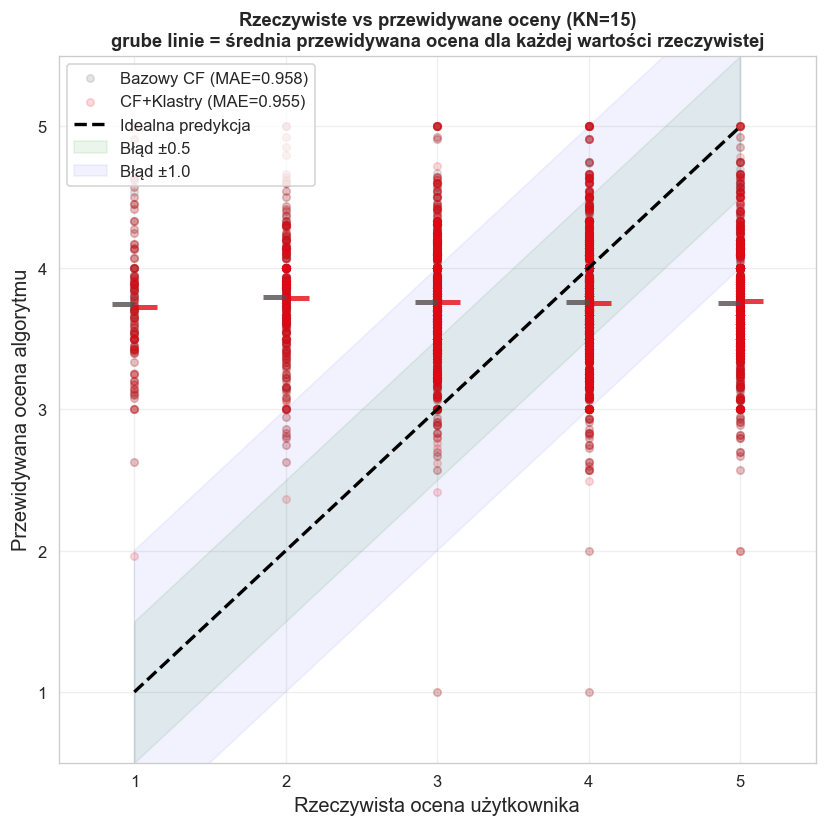

In [ ]:
# Wykres rozrzutu - czytelniejsza wersja
fig, ax = plt.subplots(figsize=(7, 7))

# Bazowy CF - szare punkty
ax.scatter(y_true_base, y_pred_base, 
           alpha=0.15, s=20, color='#564d4d', 
           label=f'Bazowy CF (MAE={mean_absolute_error(y_true_base, y_pred_base):.3f})',
           zorder=1)

# CF+Klastry - czerwone punkty
ax.scatter(y_true_best, y_pred_best, 
           alpha=0.15, s=20, color='#E50914',
           label=f'CF+Klastry (MAE={mean_absolute_error(y_true_best, y_pred_best):.3f})',
           zorder=2)

# Idealna predykcja
ax.plot([1, 5], [1, 5], 'k--', linewidth=2, label='Idealna predykcja', zorder=3)

# Strefy błędu ±0.5 i ±1.0
ax.fill_between([1, 5], [0.5, 4.5], [1.5, 5.5], 
                alpha=0.08, color='green', label='Błąd ±0.5')
ax.fill_between([1, 5], [0, 4], [2, 6],
                alpha=0.05, color='blue', label='Błąd ±1.0')

# Średnie przewidywane oceny dla każdej rzeczywistej wartości
for val in [1, 2, 3, 4, 5]:
    mask_base    = y_true_base == val
    mask_cluster = y_true_best == val
    if mask_base.sum() > 0:
        ax.hlines(y_pred_base[mask_base].mean(), val-0.15, val,
                  colors='#564d4d', linewidth=3, alpha=0.8)
    if mask_cluster.sum() > 0:
        ax.hlines(y_pred_best[mask_cluster].mean(), val, val+0.15,
                  colors='#E50914', linewidth=3, alpha=0.8)

ax.set_xlabel('Rzeczywista ocena użytkownika', fontsize=12)
ax.set_ylabel('Przewidywana ocena algorytmu', fontsize=12)
ax.set_title('Rzeczywiste vs przewidywane oceny (KN=15)\ngrube linie = średnia przewidywana ocena dla każdej wartości rzeczywistej',
             fontsize=11, fontweight='bold')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('wykres_scatter_czytelny.png', bbox_inches='tight')
plt.show()

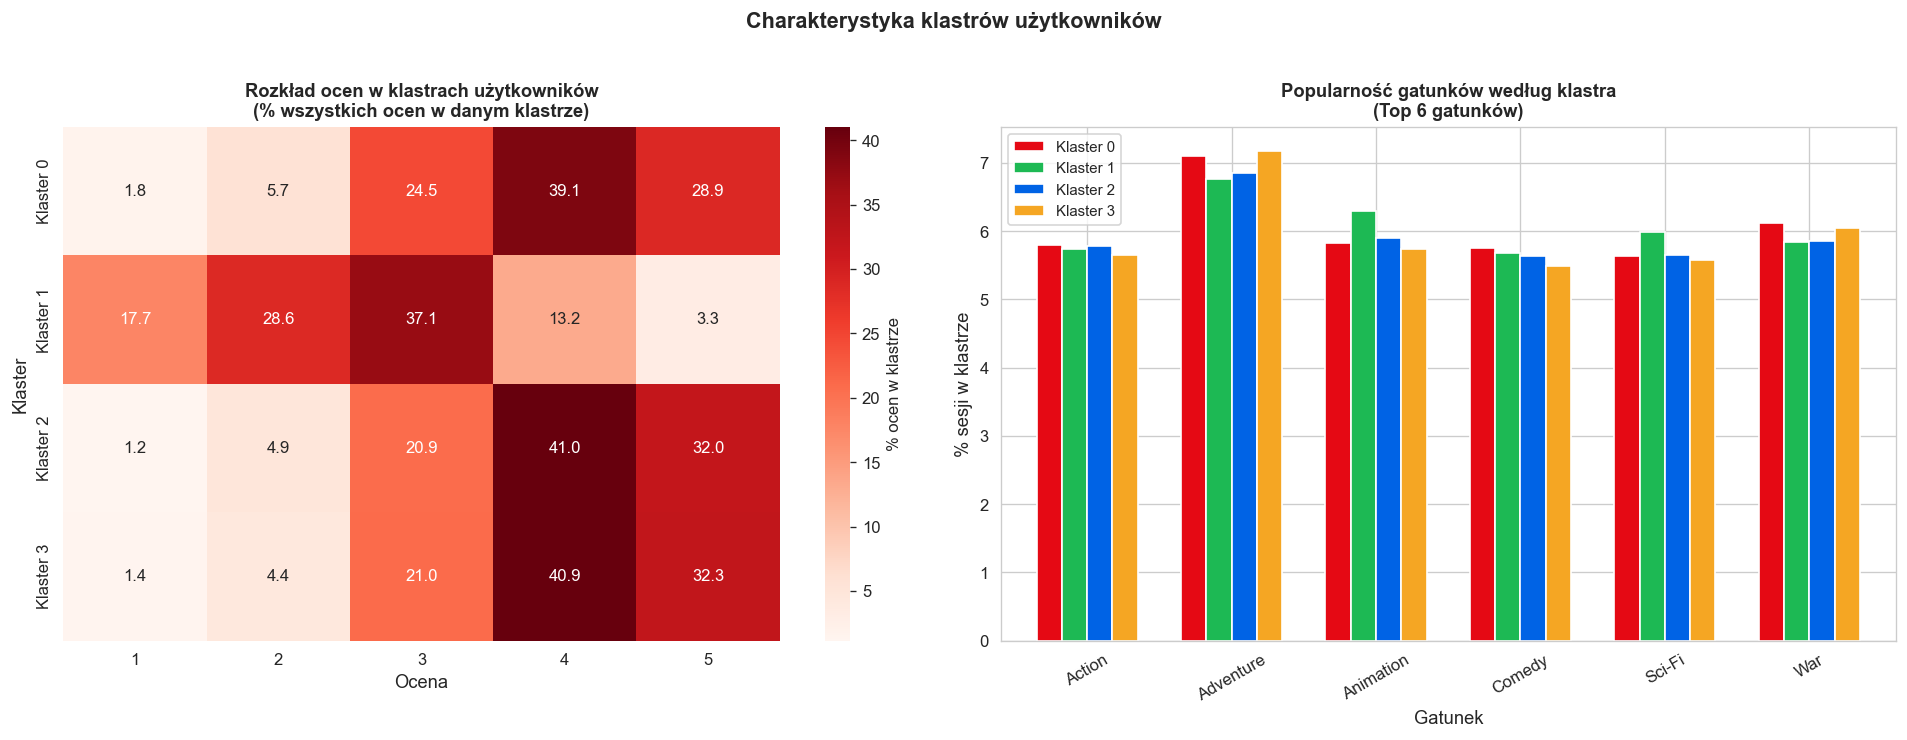

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Wykres 1: Heatmapa ocen w klastrach ---
reviews_with_cluster = reviews.merge(
    user_profiles[['user_id','cluster']], on='user_id', how='left')
reviews_with_cluster = reviews_with_cluster.dropna(subset=['cluster'])
reviews_with_cluster['cluster'] = reviews_with_cluster['cluster'].astype(int)

heat_data = reviews_with_cluster.groupby(['cluster','rating']).size().unstack(fill_value=0)
heat_pct  = heat_data.div(heat_data.sum(axis=1), axis=0) * 100

sns.heatmap(heat_pct, annot=True, fmt='.1f', cmap='Reds',
            ax=axes[0], cbar_kws={'label': '% ocen w klastrze'},
            xticklabels=[1,2,3,4,5],
            yticklabels=[f'Klaster {i}' for i in range(K_OPTIMAL)])
axes[0].set_xlabel('Ocena', fontsize=11)
axes[0].set_ylabel('Klaster', fontsize=11)
axes[0].set_title('Rozkład ocen w klastrach użytkowników\n(% wszystkich ocen w danym klastrze)',
                   fontsize=11, fontweight='bold')

# --- Wykres 2: Top gatunki w każdym klastrze ---
watch_with_cluster = watch_history.merge(
    user_profiles[['user_id','cluster']], on='user_id', how='left')
watch_with_cluster = watch_with_cluster.merge(
    movies[['movie_id','genre_primary']], on='movie_id', how='left')
watch_with_cluster = watch_with_cluster.dropna(subset=['cluster','genre_primary'])
watch_with_cluster['cluster'] = watch_with_cluster['cluster'].astype(int)

genre_cluster = watch_with_cluster.groupby(['cluster','genre_primary']).size().reset_index(name='count')
genre_cluster['pct'] = genre_cluster.groupby('cluster')['count'].transform(lambda x: x/x.sum()*100)

top_genres = genre_cluster.groupby('genre_primary')['count'].sum().nlargest(6).index
genre_top  = genre_cluster[genre_cluster['genre_primary'].isin(top_genres)]
genre_pivot = genre_top.pivot(index='genre_primary', columns='cluster', values='pct').fillna(0)

genre_pivot.plot(kind='bar', ax=axes[1], color=colors, width=0.7, edgecolor='white')
axes[1].set_xlabel('Gatunek', fontsize=11)
axes[1].set_ylabel('% sesji w klastrze', fontsize=11)
axes[1].set_title('Popularność gatunków według klastra\n(Top 6 gatunków)',
                   fontsize=11, fontweight='bold')
axes[1].legend([f'Klaster {i}' for i in range(K_OPTIMAL)], fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Charakterystyka klastrów użytkowników', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wykres_klastry_charakterystyka.png', bbox_inches='tight')
plt.show()

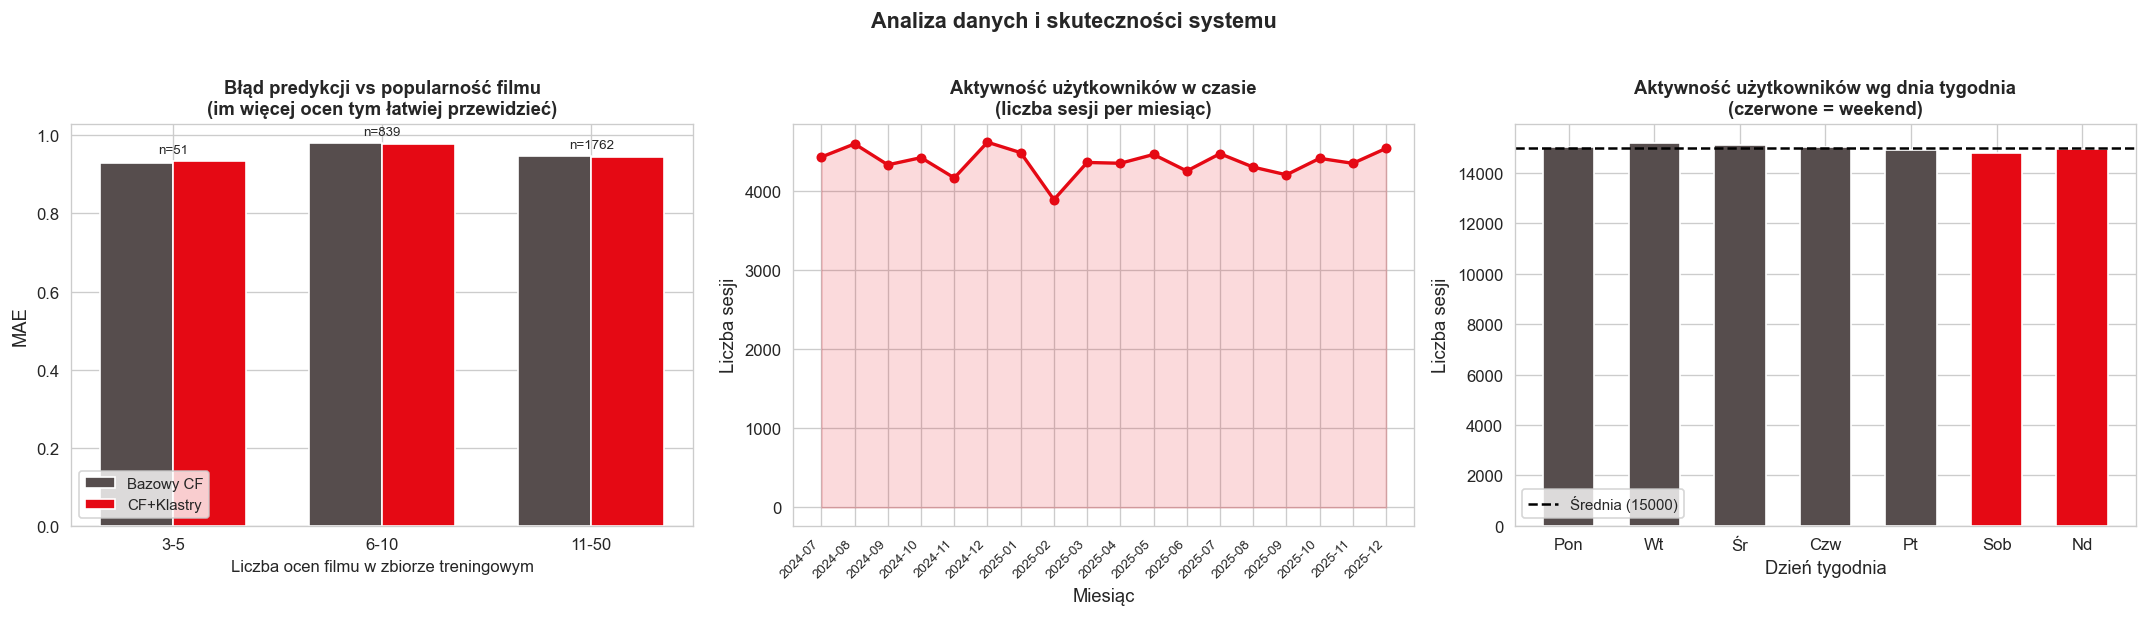

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Wykres 3: Błąd vs popularność filmu ---
movie_rating_counts = train_df.groupby('movie_id').size().reset_index(name='n_ratings')

errors_df = pd.DataFrame({
    'movie_id': test_sample['movie_id'].values,
    'error_cluster': np.abs(y_true_best - y_pred_best),
    'error_base':    np.abs(y_true_base - y_pred_base)
})
errors_df = errors_df.merge(movie_rating_counts, on='movie_id', how='left')
errors_df['popularnosc'] = pd.cut(errors_df['n_ratings'],
                                   bins=[0,2,5,10,50,1000],
                                   labels=['1-2','3-5','6-10','11-50','50+'])
errors_df = errors_df.dropna(subset=['popularnosc'])

pop_summary = errors_df.groupby('popularnosc', observed=True).agg(
    MAE_base    = ('error_base', 'mean'),
    MAE_cluster = ('error_cluster', 'mean'),
    n           = ('error_base', 'count')
).reset_index()

x = np.arange(len(pop_summary))
w = 0.35
axes[0].bar(x - w/2, pop_summary['MAE_base'],    w, color='#564d4d',
            label='Bazowy CF', edgecolor='white')
axes[0].bar(x + w/2, pop_summary['MAE_cluster'], w, color='#E50914',
            label='CF+Klastry', edgecolor='white')
for i, row in enumerate(pop_summary.itertuples()):
    axes[0].text(i, max(row.MAE_base, row.MAE_cluster) + 0.02,
                 f'n={row.n}', ha='center', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(pop_summary['popularnosc'])
axes[0].set_xlabel('Liczba ocen filmu w zbiorze treningowym', fontsize=10)
axes[0].set_ylabel('MAE', fontsize=11)
axes[0].set_title('Błąd predykcji vs popularność filmu\n(im więcej ocen tym łatwiej przewidzieć)',
                   fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# --- Wykres 4: Aktywność w czasie ---
watch_history['month'] = pd.to_datetime(watch_history['watch_date']).dt.to_period('M')
monthly = watch_history.groupby('month').size().reset_index(name='sesje')
monthly['month_str'] = monthly['month'].astype(str)
monthly = monthly.tail(18)

axes[1].plot(monthly['month_str'], monthly['sesje'],
             'o-', color='#E50914', linewidth=2, markersize=5)
axes[1].fill_between(range(len(monthly)), monthly['sesje'],
                      alpha=0.15, color='#E50914')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=8)
axes[1].set_xlabel('Miesiąc', fontsize=11)
axes[1].set_ylabel('Liczba sesji', fontsize=11)
axes[1].set_title('Aktywność użytkowników w czasie\n(liczba sesji per miesiąc)',
                   fontsize=11, fontweight='bold')

# --- Wykres 5: Aktywność wg dnia tygodnia ---
watch_history['dayofweek'] = pd.to_datetime(watch_history['watch_date']).dt.dayofweek
day_names = ['Pon','Wt','Śr','Czw','Pt','Sob','Nd']
day_counts = watch_history.groupby('dayofweek').size()

bar_colors = ['#564d4d']*5 + ['#E50914']*2
axes[2].bar(day_names, day_counts.values, color=bar_colors, edgecolor='white', width=0.6)
axes[2].set_xlabel('Dzień tygodnia', fontsize=11)
axes[2].set_ylabel('Liczba sesji', fontsize=11)
axes[2].set_title('Aktywność użytkowników wg dnia tygodnia\n(czerwone = weekend)',
                   fontsize=11, fontweight='bold')

mean_val = day_counts.mean()
axes[2].axhline(y=mean_val, color='black', linestyle='--',
                linewidth=1.5, label=f'Średnia ({mean_val:.0f})')
axes[2].legend(fontsize=9)

plt.suptitle('Analiza danych i skuteczności systemu', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wykres_analiza_danych.png', bbox_inches='tight')
plt.show()

Obliczanie krzywej uczenia się...
  10% danych treningowych (1,236 ocen): MAE Bazowy=1.092  MAE Klastry=0.959
  20% danych treningowych (2,472 ocen): MAE Bazowy=1.052  MAE Klastry=0.959
  30% danych treningowych (3,708 ocen): MAE Bazowy=1.028  MAE Klastry=0.960
  40% danych treningowych (4,944 ocen): MAE Bazowy=0.996  MAE Klastry=0.959
  50% danych treningowych (6,180 ocen): MAE Bazowy=0.982  MAE Klastry=0.958
  60% danych treningowych (7,416 ocen): MAE Bazowy=0.971  MAE Klastry=0.956
  70% danych treningowych (8,652 ocen): MAE Bazowy=0.966  MAE Klastry=0.955
  80% danych treningowych (9,888 ocen): MAE Bazowy=0.965  MAE Klastry=0.956
  90% danych treningowych (11,124 ocen): MAE Bazowy=0.964  MAE Klastry=0.955


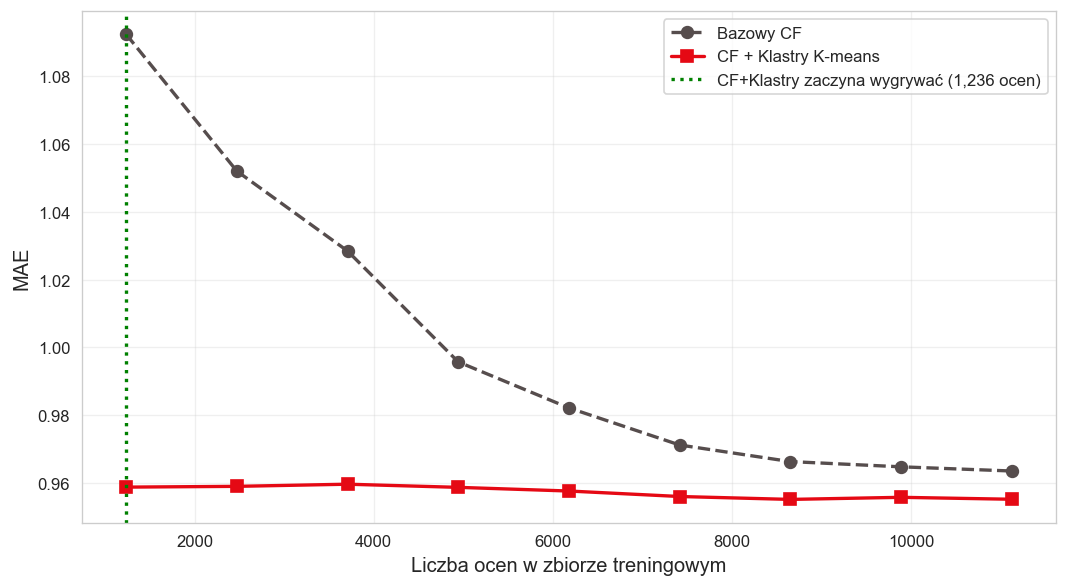

In [ ]:
# Krzywa uczenia się — jak MAE zmienia się wraz z wielkością zbioru treningowego
from sklearn.model_selection import train_test_split

train_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
mae_base_curve    = []
mae_cluster_curve = []
n_train_sizes     = []

print('Obliczanie krzywej uczenia się...')
for size in train_sizes:
    # Podziel dane treningowe na mniejszy podzbiór
    train_sub, _ = train_test_split(train_df, train_size=size, random_state=42)
    
    # Zbuduj macierz dla podzbioru
    train_sub_matrix = csr_matrix(
        (train_sub['rating'].values,
         (train_sub['u_idx'].values, train_sub['m_idx'].values)),
        shape=(n_users, n_movies)
    )
    
    # Ewaluacja na stałym zbiorze testowym (500 próbek)
    yt_b, yp_b = predict_ratings_knn(
        test_sample, train_sub_matrix, n_neighbors=15)
    yt_c, yp_c = predict_ratings_cluster_cf(
        test_sample, train_sub, user_profiles, user2idx,
        train_matrix, movie2idx, n_neighbors=15)
    
    mae_base_curve.append(mean_absolute_error(yt_b, yp_b))
    mae_cluster_curve.append(mean_absolute_error(yt_c, yp_c))
    n_train_sizes.append(len(train_sub))
    print(f'  {size*100:.0f}% danych treningowych ({len(train_sub):,} ocen): '
          f'MAE Bazowy={mae_base_curve[-1]:.3f}  MAE Klastry={mae_cluster_curve[-1]:.3f}')

# Wykres
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(n_train_sizes, mae_base_curve, 'o--', color='#564d4d',
        linewidth=2, markersize=7, label='Bazowy CF')
ax.plot(n_train_sizes, mae_cluster_curve, 's-', color='#E50914',
        linewidth=2, markersize=7, label='CF + Klastry K-means')

# Zaznacz punkt gdzie CF+Klastry zaczyna wygrywać
crossover = next((i for i in range(len(mae_base_curve))
                  if mae_cluster_curve[i] < mae_base_curve[i]), None)
if crossover is not None:
    ax.axvline(x=n_train_sizes[crossover], color='green',
               linestyle=':', linewidth=2,
               label=f'CF+Klastry zaczyna wygrywać ({n_train_sizes[crossover]:,} ocen)')

ax.set_xlabel('Liczba ocen w zbiorze treningowym', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Adnotacja — pełny zbiór treningowy
ax.annotate(f'Pełny zbiór\n({len(train_df):,} ocen)',
            xy=(len(train_df), mae_cluster_curve[-1]),
            xytext=(len(train_df)*0.7, mae_cluster_curve[-1]+0.02),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)

plt.tight_layout()
plt.savefig('wykres_krzywa_uczenia.png', bbox_inches='tight')
plt.show()

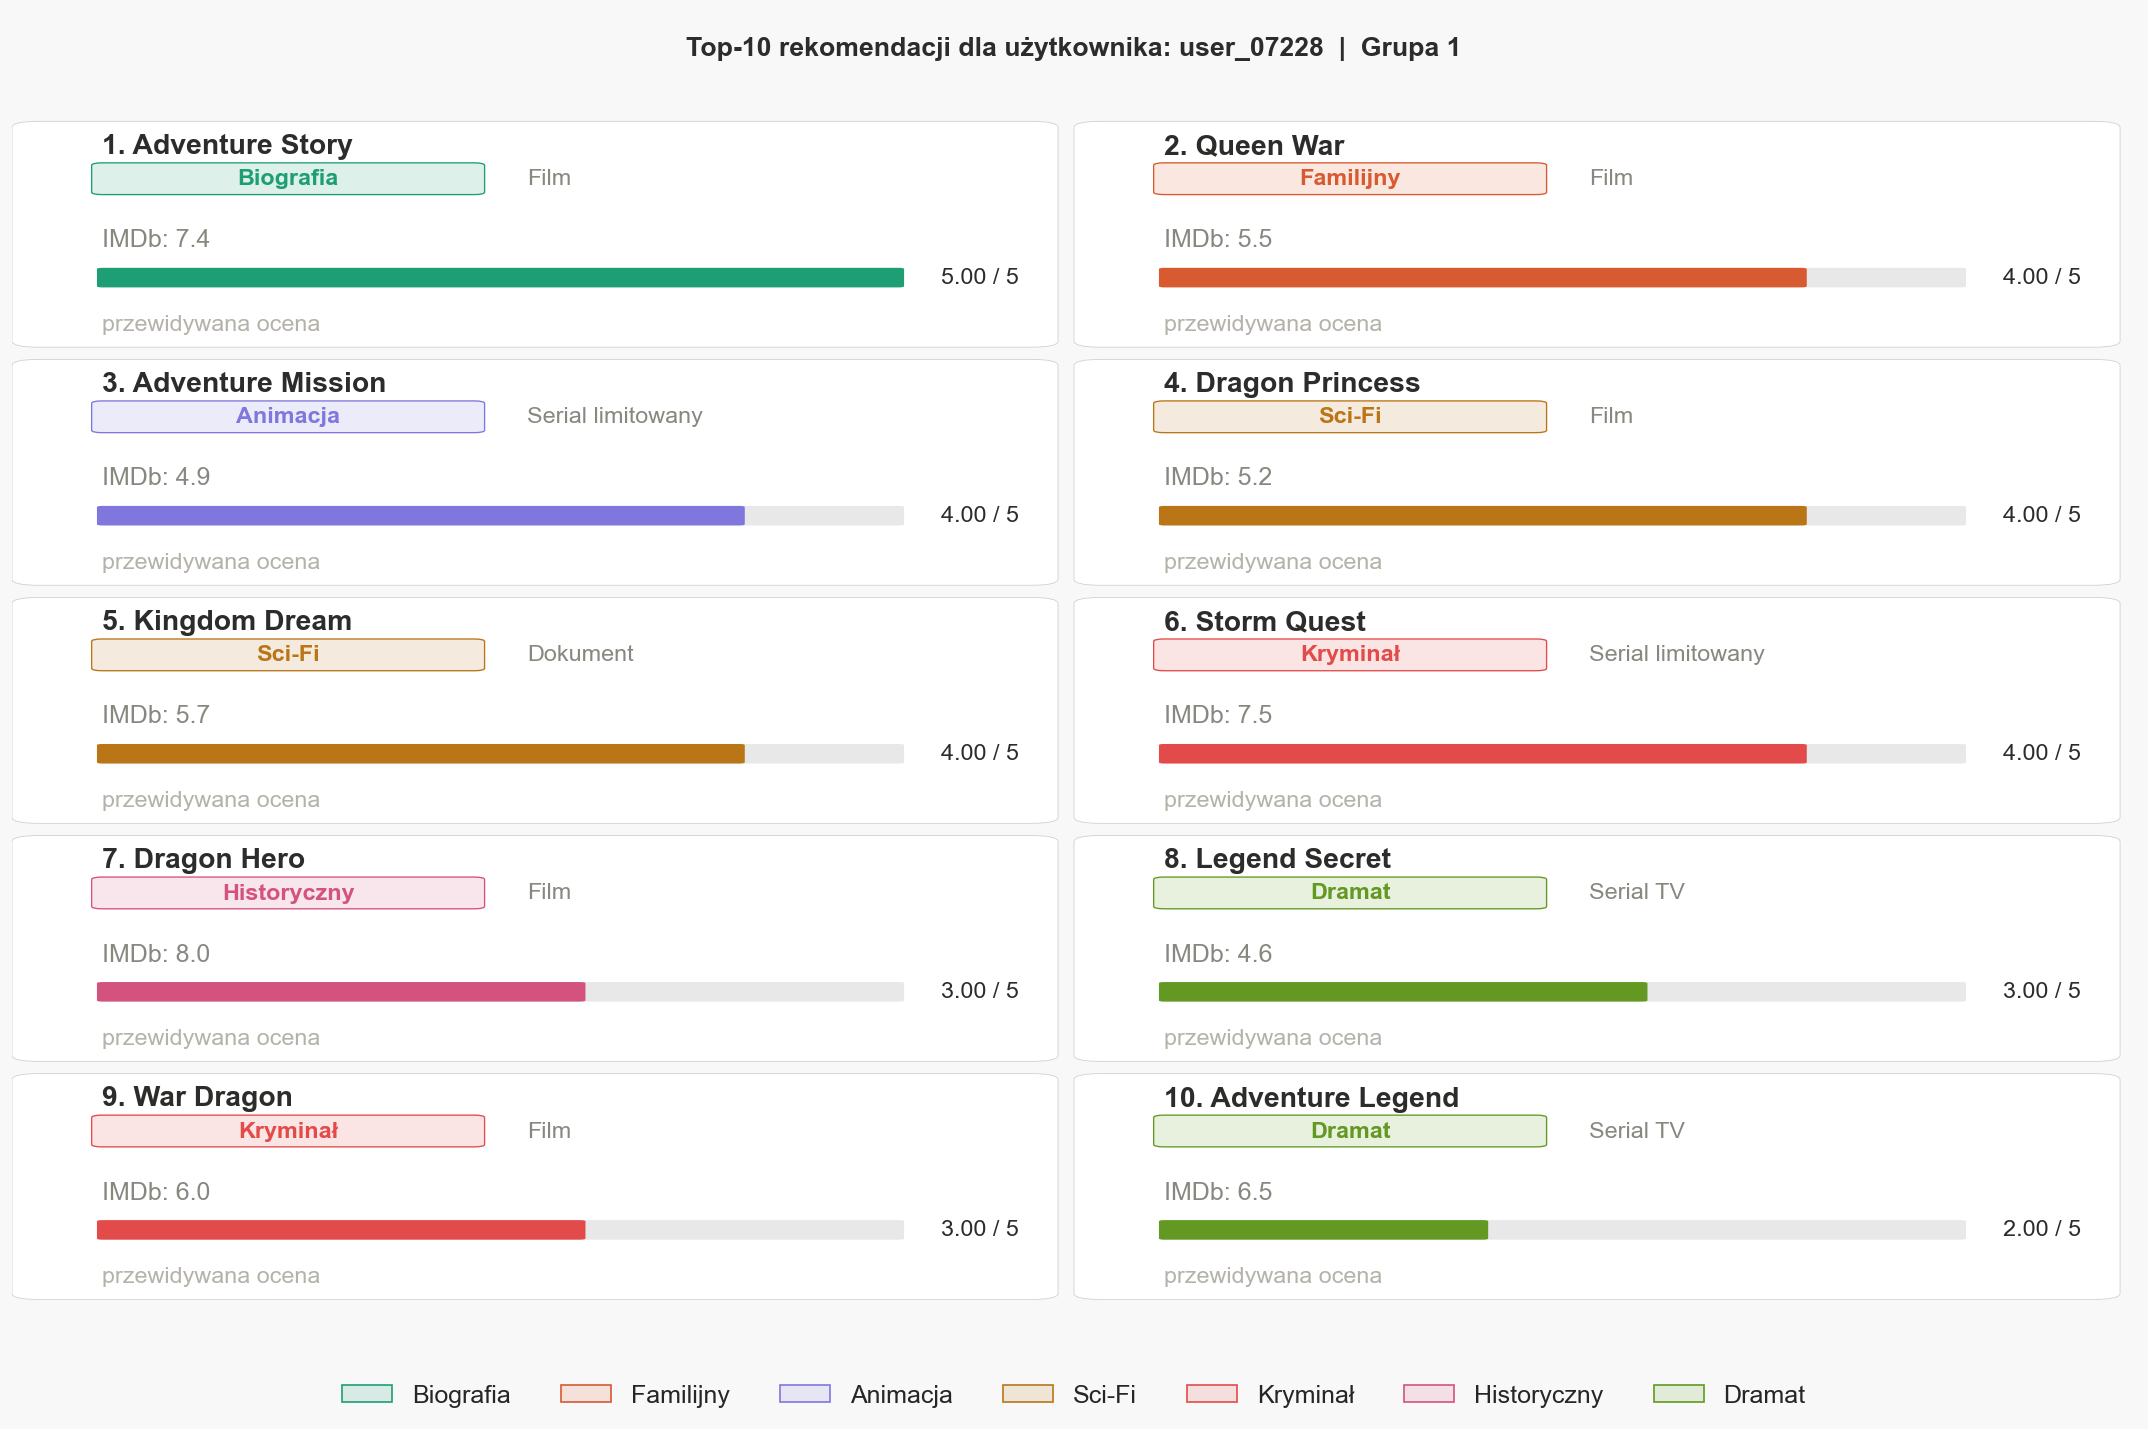

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

genre_pl = {
    "Biography": "Biografia",
    "Family": "Familijny",
    "Animation": "Animacja",
    "Sci-Fi": "Sci-Fi",
    "Mystery": "Kryminał",
    "History": "Historyczny",
    "Drama": "Dramat",
    "Crime": "Kryminał",
    "Action": "Akcja",
    "Comedy": "Komedia",
    "Horror": "Horror",
    "Romance": "Romans",
    "Thriller": "Thriller",
    "Documentary": "Dokumentalny",
    "Adventure": "Przygodowy",
    "Fantasy": "Fantasy",
}

type_pl = {
    "Movie": "Film",
    "TV Series": "Serial TV",
    "Limited Series": "Serial limitowany",
    "Documentary": "Dokument",
}

if recs is not None:
    films = []
    for _, row in recs.iterrows():
        films.append({
            "title": row["title"],
            "genre": genre_pl.get(row["genre_primary"], row["genre_primary"]),
            "score": row["predicted_rating"],
            "type":  type_pl.get(row["content_type"], row["content_type"]),
            "imdb":  row["imdb_rating"]
        })

    genres  = [genre_pl.get(g, g) for g in recs["genre_primary"].unique()]
    palette = ["#1D9E75","#D85A30","#7F77DD","#BA7517","#185FA5","#D4537E","#639922","#E24B4A"]
    genre_colors = {g: palette[i % len(palette)] for i, g in enumerate(genres)}

    fig, ax = plt.subplots(figsize=(18, 12))
    ax.set_xlim(0, 4)
    ax.set_ylim(-0.5, 11)
    ax.axis("off")
    fig.patch.set_facecolor("#F8F8F8")

    ax.text(2, 10.7,
            f"Top-10 rekomendacji dla użytkownika: {example_user}  |  Grupa {u_cluster}",
            ha="center", va="center", fontsize=16, fontweight="bold", color="#2C2C2A")

    cols = 2
    for i, film in enumerate(films):
        row_i = i // cols
        col_i = i % cols
        x = col_i * 2 + 0.05
        y = 10.0 - row_i * 1.95

        box = FancyBboxPatch((x, y - 1.7), 1.87, 1.75,
                              boxstyle="round,pad=0.05",
                              linewidth=0.5,
                              edgecolor="#D3D1C7",
                              facecolor="white")
        ax.add_patch(box)

        color = genre_colors.get(film["genre"], "#888780")

        # Numer i tytuł
        ax.text(x + 0.12, y + 0.0,
                f"{i+1}. {film['title']}",
                fontsize=17, fontweight="bold", color="#2C2C2A", va="top")

        # Badge gatunku
        badge = FancyBboxPatch((x + 0.12, y - 0.48), 0.7, 0.22,
                                boxstyle="round,pad=0.02",
                                linewidth=0.8,
                                facecolor=color + "25",
                                edgecolor=color)
        ax.add_patch(badge)
        ax.text(x + 0.47, y - 0.37, film["genre"],
                fontsize=14, color=color, va="center", ha="center", fontweight="bold")

        # Typ
        ax.text(x + 0.92, y - 0.37, film["type"],
                fontsize=14, color="#888780", va="center")

        # IMDb
        ax.text(x + 0.12, y - 0.78,
                f"IMDb: {film['imdb']:.1f}",
                fontsize=15, color="#888780", va="top")

        # Słupek oceny
        max_bar = 1.5
        bar_w   = film["score"] / 5 * max_bar
        ax.add_patch(FancyBboxPatch((x + 0.12, y - 1.25), max_bar, 0.14,
                                     boxstyle="round,pad=0.01",
                                     facecolor="#E8E8E8",
                                     edgecolor="none"))
        ax.add_patch(FancyBboxPatch((x + 0.12, y - 1.25), bar_w, 0.14,
                                     boxstyle="round,pad=0.01",
                                     facecolor=color,
                                     edgecolor="none"))
        ax.text(x + 0.12 + max_bar + 0.08, y - 1.18,
                f"{film['score']:.2f} / 5",
                fontsize=14, color="#2C2C2A", va="center")

        ax.text(x + 0.12, y - 1.48,
                "przewidywana ocena",
                fontsize=14, color="#B4B2A9", va="top")

    legend_elements = [mpatches.Patch(facecolor=c + "25", edgecolor=c, label=g)
                       for g, c in genre_colors.items()]
    ax.legend(handles=legend_elements, loc="lower center",
              bbox_to_anchor=(0.5, -0.01), ncol=len(genre_colors),
              frameon=False, fontsize=15)

    plt.tight_layout()
    plt.savefig("rekomendacje_panel.png", bbox_inches="tight", dpi=200)
    plt.show()

## 8. Podsumowanie wynikow

In [ ]:
mae_b_avg  = results_df['MAE_base'].mean()
mae_c_avg  = results_df['MAE_cluster'].mean()
rmse_b_avg = results_df['RMSE_base'].mean()
rmse_c_avg = results_df['RMSE_cluster'].mean()
imp_mae    = (mae_b_avg - mae_c_avg) / mae_b_avg * 100
imp_rmse   = (rmse_b_avg - rmse_c_avg) / rmse_b_avg * 100

print('=' * 55)
print('PODSUMOWANIE WYNIKOW')
print('=' * 55)
print(f'  Metoda               | Sr. MAE | Sr. RMSE')
print(f'  Bazowy CF (user-KNN) | {mae_b_avg:.3f}   | {rmse_b_avg:.3f}')
print(f'  CF + Klastry K-means | {mae_c_avg:.3f}   | {rmse_c_avg:.3f}')
print(f'  Poprawa MAE:   {imp_mae:+.1f}%')
print(f'  Poprawa RMSE:  {imp_rmse:+.1f}%')
print('=' * 55)
best_k = results_df.loc[results_df['MAE_cluster'].idxmin(), 'KN']
print(f'  Najlepsze k (CF+Klastry): {best_k}')

PODSUMOWANIE WYNIKOW
  Metoda               | Sr. MAE | Sr. RMSE
  Bazowy CF (user-KNN) | 0.959   | 1.185
  CF + Klastry K-means | 0.956   | 1.183
  Poprawa MAE:   +0.3%
  Poprawa RMSE:  +0.2%
  Najlepsze k (CF+Klastry): 10
